<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%208/W08_L1_Attention_in_Vision_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=gYACi7Tq1y4) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%208/NPTEL_Jul24_DL4CV_W08_P01.pdf)

In [1]:
# Week 8, Lecture 1: Attention in Vision Models
from IPython.display import HTML, display

VIDEO_ID = "gYACi7Tq1y4"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 8, Lecture 1: Attention Models in Vision: An Introduction

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§8.1 Attention Models in Vision**.

This notebook follows the lecture's route into attention: it starts with the encoder-decoder idea and its
simplest instance, the autoencoder, shows with a trained sequence-to-sequence model why a single context
vector is an **information bottleneck**, and then builds the attention mechanism that removes it, first over
time-steps and then over the spatial grid of a CNN.

**What you will learn**

- The **encoder-decoder** pattern, and **autoencoders** as its unsupervised special case, trained with
  $L = \|x - \hat x\|_2^2$; **denoising** autoencoders; **undercomplete** versus **overcomplete** codes.
- The slide's homework, answered by experiment: a **linear undercomplete autoencoder on centered data
  with MSE loss finds exactly the PCA subspace**, verified on the projection matrices.
- Why a fixed-length context vector fails on long inputs: a seq2seq model whose accuracy **degrades with
  input length**, the analogue of the BLEU curve in the slides.
- The attention mechanism $c_t = \sum_j \alpha_{t,j} h_j$ with
  $\alpha_{t,j} = \operatorname{softmax}_j\, score(s_{t-1}, h_j)$, added to the same model, and what it
  does to that curve.
- The six **alignment score functions** of the slides, implemented, trained and related to each other.
- **Space-steps**: a decoder that attends over a CNN feature grid to answer "where is the red square?",
  with the attention map overlaid on the image, and why the fully connected vector cannot do this.
- Attention weights as a **byproduct for explainability**, and the **modes** of attention: hard versus
  soft, global versus local, and self-attention.

**Contents**

1. Encoder-decoder modeling
2. Autoencoders
3. Denoising autoencoders
4. Undercomplete, overcomplete, and the PCA homework
5. Seq2seq and the information bottleneck
6. The attention mechanism
7. Alignment score functions
8. From time-steps to space-steps
9. Byproduct of attention: explainability
10. Modes of attention
11. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU
needed). Run the setup cell first, then go top to bottom.

## Review

The previous lecture closed with a question: what happens if you train a model on normal videos and run it
on a reversed video? The slides answer that it depends on the task. Telling walking from jumping may survive
the reversal, recognising a tennis forehand will not, and finding the arrow of time is itself a learnable
problem (*Wei et al., CVPR 2018*). Week 7 established the tools behind such models: RNNs model sequential
data, they are trained with backpropagation through time, they suffer from vanishing and exploding
gradients, gradient clipping controls the second, and the gates of LSTMs and GRUs mitigate the first.

The slides then ask: *is this modeling sufficient?* An RNN encoder folds the whole input into one hidden
state, and an RNN decoder has to generate everything from that one vector. This lecture shows where that
breaks and introduces the mechanism, attention, that fixes it.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed, SelectionSlider
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed, SelectionSlider

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100

def count_params(m):
    """Number of trainable parameters of a module."""
    return sum(p.numel() for p in m.parameters())

def to_np(x):
    """Tensor (any device) -> numpy, for matplotlib."""
    return x.detach().cpu().numpy()

print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. Encoder-decoder modeling

The lecture opens with two RNN tasks, **image captioning** and **neural machine translation**, and the one
pattern behind both: **encoder-decoder modeling**. An encoder reads the input (an image through a CNN, a
sentence through an RNN) and produces a representation; a decoder generates the output from that
representation, one token at a time.

For a sequence input $x_1, \dots, x_T$ the encoder is an RNN whose hidden state $h_j$ summarises the
input around position $j$. The decoder is a second RNN, started from the encoder's final state, that
produces $y_1, y_2, \dots$:

$$h_j = \mathrm{RNN}_{\text{enc}}(h_{j-1}, x_j), \qquad s_0 = h_T, \qquad s_t = \mathrm{RNN}_{\text{dec}}(s_{t-1}, y_{t-1}).$$

The encoder below is **bidirectional**, the design of *Bahdanau et al., ICLR 2015*: one GRU reads left to
right, another right to left, and $h_j$ is the concatenation of the two states at position $j$, so that
each $h_j$ knows both what precedes and what follows token $j$. The context vector $h_T$ concatenates the
forward state at the last token with the backward state at the first one.

The single vector $h_T$ that connects the two halves is the **context vector**. Two things about it are
worth measuring before going further: its size does not depend on $T$, and neither does the number of
parameters. That is the strength of the design and, as Section 5 shows, also its weakness.

In [3]:
class GRUEncoder(nn.Module):
    """Bidirectional GRU encoder (as in Bahdanau et al.): h_j = [forward state ; backward state] at token j."""
    def __init__(self, n_tokens, d):
        super().__init__()
        self.emb = nn.Embedding(n_tokens, d)
        self.rnn = nn.GRU(d, d // 2, batch_first=True, bidirectional=True)

    def forward(self, x, lengths=None):
        """Returns all states H (B, T, d) and the context vector h_T (B, d).

        In a padded batch every sequence has its own last token, so h_T is assembled from the forward
        state at that token and the backward state at the first token, never from the padding.
        """
        H, _ = self.rnn(self.emb(x))
        B = x.shape[0]
        if lengths is None:
            lengths = torch.full((B,), x.shape[1], device=x.device)
        half = H.shape[-1] // 2
        h_fwd = H[torch.arange(B, device=x.device), lengths - 1, :half]
        h_bwd = H[:, 0, half:]
        return H, torch.cat([h_fwd, h_bwd], dim=-1)


d_model = 32
enc_demo = GRUEncoder(12, d_model).to(device)
print(f'encoder parameters: {count_params(enc_demo)}  (independent of the input length T)')
for T in (5, 50, 500):
    x = torch.randint(0, 10, (2, T), device=device)
    H, h_T = enc_demo(x)
    assert tuple(h_T.shape) == (2, d_model), 'the context vector must have a fixed size'
    print(f'  T = {T:3d}: all states H {tuple(H.shape)}  ->  context vector h_T {tuple(h_T.shape)}')
print(f'\n{d_model} numbers have to carry everything the decoder will ever know about the input')

encoder parameters: 5184  (independent of the input length T)
  T =   5: all states H (2, 5, 32)  ->  context vector h_T (2, 32)
  T =  50: all states H (2, 50, 32)  ->  context vector h_T (2, 32)
  T = 500: all states H (2, 500, 32)  ->  context vector h_T (2, 32)

32 numbers have to carry everything the decoder will ever know about the input


## 2. Autoencoders

The simplest encoder-decoder is one whose target is its own input. The slide defines it:

> "An autoencoder neural network is an unsupervised learning model that applies backpropagation, setting
> target values to be equal to inputs themselves, i.e. $y_i = x_i$."

It learns a function $f_{W,b}(x) \approx x$, an approximation to the identity, and the slide's answer to
"loss function?" is the **mean squared error** $L = \|x - \hat x\|_2^2$. Both encoder and decoder can have
many layers (a **deep autoencoder**), and in the standard design the decoder mirrors the encoder, though
the slide notes this is not required.

The code below trains one on a 10 000-image subset of MNIST. The encoder is $784 \to 256 \to k$, the
decoder mirrors it, and $k$ is the width of the **bottleneck**, the code that every image has to pass
through.

In [4]:
# MNIST subset, loaded once into tensors on `device` (28x28 images flattened to 784).
mnist_tr = datasets.MNIST(root='./data', train=True, download=True)
mnist_te = datasets.MNIST(root='./data', train=False, download=True)
N_TR, N_TE = 10000, 2000
Xtr = mnist_tr.data[:N_TR].float().div(255).reshape(-1, 784).to(device)
Xte = mnist_te.data[:N_TE].float().div(255).reshape(-1, 784).to(device)
ytr = mnist_tr.targets[:N_TR].to(device)
yte = mnist_te.targets[:N_TE].to(device)
print(f'train {tuple(Xtr.shape)}  test {tuple(Xte.shape)}  pixel range [{Xtr.min():.0f}, {Xtr.max():.0f}]')


class AutoEncoder(nn.Module):
    """784 -> 256 -> k -> 256 -> 784 with ReLU; the decoder mirrors the encoder."""
    def __init__(self, k, hidden=256):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(784, hidden), nn.ReLU(), nn.Linear(hidden, k))
        self.decoder = nn.Sequential(nn.Linear(k, hidden), nn.ReLU(), nn.Linear(hidden, 784), nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x))


def mse_scratch(x_hat, x):
    """The slide's loss ||x - x_hat||^2, averaged over pixels and images (what F.mse_loss computes)."""
    return ((x - x_hat) ** 2).mean()


def train_ae(k, epochs=4, noise=0.0, lr=2e-3, batch=128, seed=0, log=False):
    """Train AutoEncoder(k) by MSE against the CLEAN input.

    noise > 0 corrupts the input with Gaussian noise of that std before encoding, which turns the
    model into a denoising autoencoder (Section 3). Returns the model and its test MSE on clean inputs.
    """
    set_seed(seed)
    net = AutoEncoder(k).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for ep in range(epochs):
        perm = torch.randperm(N_TR).to(device)
        tot = 0.0
        for i in range(0, N_TR, batch):
            x = Xtr[perm[i:i + batch]]
            x_in = x + noise * torch.randn_like(x) if noise > 0 else x
            loss = mse_scratch(net(x_in), x)          # target is always the uncorrupted x
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(x)
        if log:
            print(f'  epoch {ep + 1}: train MSE {tot / N_TR:.4f}')
    net.eval()
    with torch.no_grad():
        test_mse = F.mse_loss(net(Xte), Xte).item()
    return net, test_mse


# the from-scratch loss is F.mse_loss
_a, _b = torch.rand(5, 784, device=device), torch.rand(5, 784, device=device)
assert torch.allclose(mse_scratch(_a, _b), F.mse_loss(_a, _b)), 'MSE mismatch'

t0 = time.time()
ae32, ae32_mse = train_ae(k=32, log=True)
print(f'k = 32: test MSE {ae32_mse:.4f}, trained in {time.time() - t0:.1f} s, {count_params(ae32)} parameters')

train (10000, 784)  test (2000, 784)  pixel range [0, 1]
  epoch 1: train MSE 0.0741


  epoch 2: train MSE 0.0340


  epoch 3: train MSE 0.0243
  epoch 4: train MSE 0.0194
k = 32: test MSE 0.0191, trained in 0.3 s, 419120 parameters


The reconstructions below come from a 32-number code. The digits come back slightly blurred, which is
what "an approximation to the identity" looks like when 784 pixels have to squeeze through 32 units.

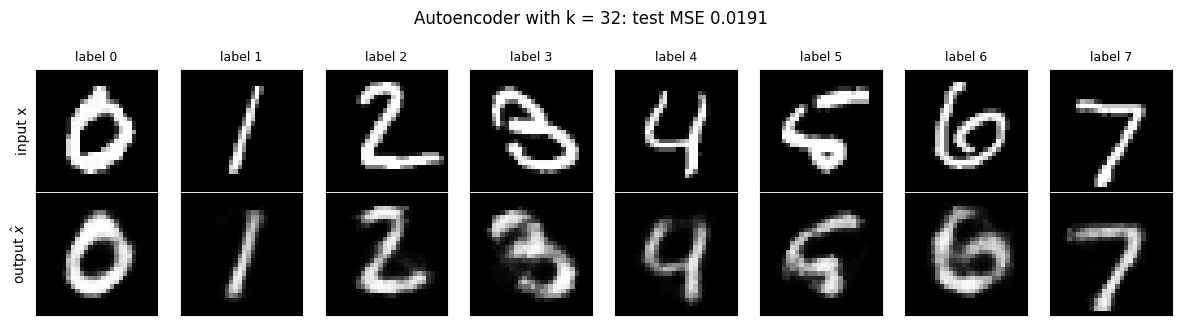

In [5]:
demo_idx = torch.tensor([3, 2, 1, 18, 4, 8, 11, 0], device=device)    # one example of each of 8 digits
with torch.no_grad():
    recon32 = ae32(Xte[demo_idx])

fig, ax = plt.subplots(2, 8, figsize=(12, 3.2))
for j in range(8):
    ax[0, j].imshow(to_np(Xte[demo_idx[j]]).reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax[1, j].imshow(to_np(recon32[j]).reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax[0, j].set_title(f'label {int(yte[demo_idx[j]])}', fontsize=9)
    for a_ in ax[:, j]: a_.set_xticks([]); a_.set_yticks([])
ax[0, 0].set_ylabel('input x'); ax[1, 0].set_ylabel('output $\\hat x$')
fig.suptitle(f'Autoencoder with k = 32: test MSE {ae32_mse:.4f}', y=1.0)
plt.tight_layout(); plt.show()

### 2.a The bottleneck width

How much of the image survives depends on $k$. The sweep below trains one autoencoder per bottleneck
width (each takes well under a second) and records its test MSE and its reconstruction of the same digits.
The error falls steeply from $k = 2$ to $k = 16$ and then flattens: beyond a few dozen dimensions the extra
code capacity buys little, which is the first hint that MNIST lives near a low-dimensional manifold, a
point the slides return to under "undercomplete autoencoders".

  k =   2: test MSE 0.0496


  k =   4: test MSE 0.0387


  k =   8: test MSE 0.0274


  k =  16: test MSE 0.0213


  k =  32: test MSE 0.0191


  k =  64: test MSE 0.0184


  k = 128: test MSE 0.0177
sweep over 7 bottleneck widths in 2.3 s


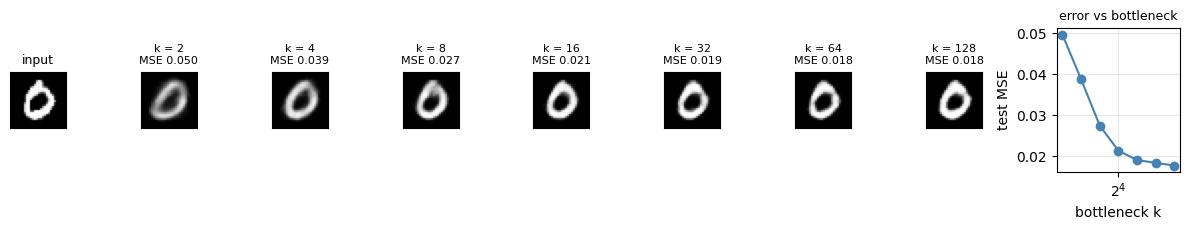

In [6]:
KS = [2, 4, 8, 16, 32, 64, 128]
sweep_recon, sweep_mse = {}, {}
t0 = time.time()
for k in KS:
    net_k, mse_k = train_ae(k)
    with torch.no_grad():
        sweep_recon[k] = to_np(net_k(Xte[demo_idx])).reshape(-1, 28, 28)
    sweep_mse[k] = mse_k
    print(f'  k = {k:3d}: test MSE {mse_k:.4f}')
print(f'sweep over {len(KS)} bottleneck widths in {time.time() - t0:.1f} s')
assert sweep_mse[2] > sweep_mse[16] > sweep_mse[128], 'a wider bottleneck should reconstruct better'

fig, ax = plt.subplots(1, len(KS) + 2, figsize=(12, 2.4),
                       gridspec_kw={'width_ratios': [1] * (len(KS) + 1) + [2.2]})
ax[0].imshow(to_np(Xte[demo_idx[0]]).reshape(28, 28), cmap='gray', vmin=0, vmax=1); ax[0].set_title('input', fontsize=9)
for j, k in enumerate(KS):
    ax[j + 1].imshow(sweep_recon[k][0], cmap='gray', vmin=0, vmax=1)
    ax[j + 1].set_title(f'k = {k}\nMSE {sweep_mse[k]:.3f}', fontsize=8)
for a_ in ax[:-1]: a_.set_xticks([]); a_.set_yticks([])
ax[-1].plot(KS, [sweep_mse[k] for k in KS], 'o-', color='steelblue')
ax[-1].set_xscale('log', base=2); ax[-1].set_xlabel('bottleneck k'); ax[-1].set_ylabel('test MSE')
ax[-1].grid(alpha=0.3); ax[-1].set_title('error vs bottleneck', fontsize=9)
plt.tight_layout(); plt.show()

### Widget 1: bottleneck width versus reconstruction

Drag `k` from 2 upwards and watch the eight digits sharpen. At $k = 2$ the decoder can only produce a
handful of prototypes, so several digits come back as the wrong class; by $k = 16$ every digit is
recognisable and the remaining gain is in the fine strokes. The reconstructions were computed in the sweep
above, so the slider only indexes them.

In [7]:
def show_bottleneck(k=32):
    fig, ax = plt.subplots(2, 8, figsize=(12, 3.2))
    for j in range(8):
        ax[0, j].imshow(to_np(Xte[demo_idx[j]]).reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax[1, j].imshow(sweep_recon[k][j], cmap='gray', vmin=0, vmax=1)
        for a_ in ax[:, j]: a_.set_xticks([]); a_.set_yticks([])
    ax[0, 0].set_ylabel('input'); ax[1, 0].set_ylabel(f'k = {k}')
    fig.suptitle(f'bottleneck k = {k}: test MSE {sweep_mse[k]:.4f}', y=1.0)
    plt.tight_layout(); plt.show()

interact(show_bottleneck, k=SelectionSlider(options=KS, value=32, description='k'));

interactive(children=(SelectionSlider(description='k', index=4, options=(2, 4, 8, 16, 32, 64, 128), value=32),…

## 3. Denoising autoencoders

The slide's variant: the **input is perturbed with noise** (Gaussian, for instance) but the network is
asked to **predict the original input without noise**. The loss is again the mean squared error, this time
between the output and the *uncorrupted* input:

$$L = \|x - f(x + \epsilon)\|_2^2, \qquad \epsilon \sim \mathcal N(0, \sigma^2 I).$$

`train_ae(noise=0.5)` does exactly this: the corruption is applied inside the training loop and the
target stays `x`. Note what the model cannot do: it cannot reproduce the noise, because the noise is drawn
fresh every step and is not predictable from the image. The only way to lower the loss is to learn what
digits look like and project the noisy input back onto them. That is why denoising is a good
regulariser: the code has to capture the data manifold rather than memorise pixels.

In [8]:
SIGMA_TRAIN = 0.5
t0 = time.time()
dae32, dae32_clean_mse = train_ae(k=32, noise=SIGMA_TRAIN, log=True)
print(f'denoising AE (sigma = {SIGMA_TRAIN}): test MSE on CLEAN inputs {dae32_clean_mse:.4f}, {time.time() - t0:.1f} s')

# Compare the plain AE and the DAE when the TEST input is corrupted with noise of std sigma.
SIGMAS = [round(s, 2) for s in np.arange(0.0, 1.51, 0.1)]
noise_grid = {}                 # sigma -> (noisy inputs, AE output, DAE output) for the demo digits, plus MSEs
g = torch.Generator(device='cpu').manual_seed(1)
eps_te = torch.randn(Xte.shape, generator=g).to(device)         # one fixed noise draw for the whole test set
with torch.no_grad():
    for s in SIGMAS:
        x_noisy = Xte + s * eps_te
        out_ae, out_dae = ae32(x_noisy), dae32(x_noisy)
        mse_ae, mse_dae = F.mse_loss(out_ae, Xte).item(), F.mse_loss(out_dae, Xte).item()
        noise_grid[s] = dict(noisy=to_np(x_noisy[demo_idx]).reshape(-1, 28, 28),
                             ae=to_np(out_ae[demo_idx]).reshape(-1, 28, 28),
                             dae=to_np(out_dae[demo_idx]).reshape(-1, 28, 28),
                             mse_ae=mse_ae, mse_dae=mse_dae)

print('\n  test noise sigma   plain AE MSE   denoising AE MSE   (both against the clean image)')
for s in (0.0, 0.25, 0.5, 0.75, 1.0, 1.5):
    s = min(SIGMAS, key=lambda v: abs(v - s))
    print(f'      {s:4.2f}            {noise_grid[s]["mse_ae"]:.4f}           {noise_grid[s]["mse_dae"]:.4f}')
assert noise_grid[0.5]['mse_dae'] < noise_grid[0.5]['mse_ae'], 'the DAE must beat the AE at its training noise'
print('\nthe plain AE passes the noise through; the DAE was trained to remove it')

  epoch 1: train MSE 0.0745
  epoch 2: train MSE 0.0392


  epoch 3: train MSE 0.0301
  epoch 4: train MSE 0.0263
denoising AE (sigma = 0.5): test MSE on CLEAN inputs 0.0223, 0.6 s

  test noise sigma   plain AE MSE   denoising AE MSE   (both against the clean image)
      0.00            0.0191           0.0223
      0.20            0.0215           0.0228
      0.50            0.0320           0.0261
      0.70            0.0407           0.0300
      1.00            0.0531           0.0378
      1.50            0.0688           0.0519

the plain AE passes the noise through; the DAE was trained to remove it


The comparison row below shows the same digit at increasing test noise: what the network sees, what the
plain autoencoder returns, and what the denoising autoencoder returns. The plain autoencoder was trained on
clean digits, so its encoder treats the noise as signal and its output degrades with $\sigma$. The
denoising autoencoder keeps returning a clean digit well past its training noise level.

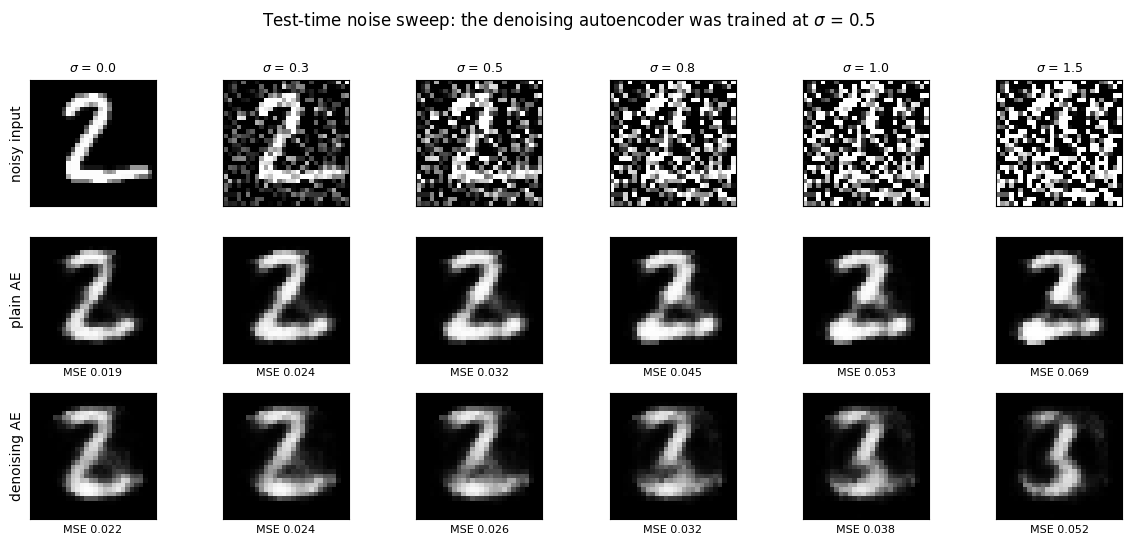

In [9]:
show_s = [0.0, 0.3, 0.5, 0.8, 1.0, 1.5]
fig, ax = plt.subplots(3, len(show_s), figsize=(12, 5.4))
for j, s in enumerate(show_s):
    gsd = noise_grid[s]
    ax[0, j].imshow(gsd['noisy'][2], cmap='gray', vmin=0, vmax=1)
    ax[1, j].imshow(gsd['ae'][2], cmap='gray', vmin=0, vmax=1)
    ax[2, j].imshow(gsd['dae'][2], cmap='gray', vmin=0, vmax=1)
    ax[0, j].set_title(f'$\\sigma$ = {s}', fontsize=9)
    ax[1, j].set_xlabel(f'MSE {gsd["mse_ae"]:.3f}', fontsize=8)
    ax[2, j].set_xlabel(f'MSE {gsd["mse_dae"]:.3f}', fontsize=8)
    for a_ in ax[:, j]: a_.set_xticks([]); a_.set_yticks([])
ax[0, 0].set_ylabel('noisy input'); ax[1, 0].set_ylabel('plain AE'); ax[2, 0].set_ylabel('denoising AE')
fig.suptitle('Test-time noise sweep: the denoising autoencoder was trained at $\\sigma$ = 0.5', y=1.0)
plt.tight_layout(); plt.show()

### Widget 2: noise level

Drag `sigma`. Up to about 0.3 both models cope; between 0.5 and 1.0 the plain autoencoder's outputs fill
with speckle and start changing identity while the denoising autoencoder's stay clean; beyond 1.2 even the
denoiser begins to guess, because the digit is genuinely buried. Everything shown was precomputed in the
sweep, so the slider is instant.

In [10]:
def show_noise(sigma=0.5):
    gsd = noise_grid[sigma]
    fig, ax = plt.subplots(3, 8, figsize=(12, 4.8))
    for j in range(8):
        ax[0, j].imshow(gsd['noisy'][j], cmap='gray', vmin=0, vmax=1)
        ax[1, j].imshow(gsd['ae'][j], cmap='gray', vmin=0, vmax=1)
        ax[2, j].imshow(gsd['dae'][j], cmap='gray', vmin=0, vmax=1)
        for a_ in ax[:, j]: a_.set_xticks([]); a_.set_yticks([])
    ax[0, 0].set_ylabel('noisy input'); ax[1, 0].set_ylabel('plain AE'); ax[2, 0].set_ylabel('denoising AE')
    fig.suptitle(f'sigma = {sigma:.1f}:  plain AE MSE {gsd["mse_ae"]:.4f}   denoising AE MSE {gsd["mse_dae"]:.4f}', y=1.0)
    plt.tight_layout(); plt.show()

interact(show_noise, sigma=SelectionSlider(options=SIGMAS, value=0.5, description='sigma'));

interactive(children=(SelectionSlider(description='sigma', index=5, options=(np.float64(0.0), np.float64(0.1),…

## 4. Undercomplete, overcomplete, and the PCA homework

The slides ask why the hidden layer should be smaller than the input, and answer in two lines:

> "Autoencoder (AE) with hidden layer with lesser dimension than input layer called **undercomplete** AE
> $\Rightarrow$ AE learns a lower-dimensional representation on suitable manifold of input data."
>
> "Autoencoder (AE) with hidden layer with higher dimension than input layer called **overcomplete** AE
> $\Rightarrow$ AE could learn trivial solutions, by copying input."

The second claim is easy to test. A linear autoencoder $\hat x = x W_e W_d$ with $k > 784$ can make
$W_e W_d = I$ exactly. The tell-tale sign of a copying solution is that it reconstructs its input almost
perfectly and also reproduces things it never saw, such as images of pure noise, whereas an undercomplete
code reconstructs only what lies in the subspace it has learned.

In [11]:
class LinearAE(nn.Module):
    """x -> h = x W_e -> x_hat = h W_d. No biases, no nonlinearity: the slide's H W* form."""
    def __init__(self, k, n_in=784):
        super().__init__()
        self.We = nn.Linear(n_in, k, bias=False)
        self.Wd = nn.Linear(k, n_in, bias=False)

    def encode(self, x):
        return self.We(x)

    def forward(self, x):
        return self.Wd(self.We(x))


def train_linear_ae(X, k, steps, lr, batch=None, seed=0):
    """Minimise the mean per-image squared error ||x - x_hat||^2 (the slide's Frobenius objective / m)."""
    set_seed(seed)
    net = LinearAE(k, X.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for it in range(steps):
        xb = X if batch is None else X[torch.randint(0, len(X), (batch,), device=device)]
        loss = ((net(xb) - xb) ** 2).sum(1).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return net


mu = Xtr.mean(0, keepdim=True)                 # per-pixel mean, used to centre the data
Xc_tr, Xc_te = Xtr - mu, Xte - mu
X_noise = torch.rand(500, 784, device=device) - mu    # 500 images of uniform noise, centred the same way

t0 = time.time()
under = train_linear_ae(Xc_tr, k=16, steps=400, lr=1e-2)
over = train_linear_ae(Xc_tr, k=1024, steps=400, lr=1e-3, batch=256)
print(f'trained linear AEs with k = 16 (undercomplete) and k = 1024 (overcomplete) in {time.time() - t0:.1f} s')

def per_image_err(net, X):
    with torch.no_grad():
        return ((net(X) - X) ** 2).sum(1).mean().item()

I = torch.eye(784, device=device)
with torch.no_grad():
    W_prod_over = over.Wd.weight @ over.We.weight       # the end-to-end linear map of the overcomplete AE
    W_prod_under = under.Wd.weight @ under.We.weight
print('\n                          digits error    noise-image error    ||W_d W_e - I||_F / ||I||_F')
print(f'  undercomplete k = 16      {per_image_err(under, Xc_te):8.2f}        {per_image_err(under, X_noise):8.2f}              {torch.norm(W_prod_under - I) / torch.norm(I):.3f}')
print(f'  overcomplete  k = 1024    {per_image_err(over, Xc_te):8.2f}        {per_image_err(over, X_noise):8.2f}              {torch.norm(W_prod_over - I) / torch.norm(I):.3f}')
print(f'  (for scale: ||x||^2 of a centred noise image is {(X_noise ** 2).sum(1).mean():.1f})')
assert per_image_err(over, Xc_te) < 0.05 * per_image_err(under, Xc_te), 'the overcomplete AE should copy digits'
assert per_image_err(over, X_noise) < 0.6 * per_image_err(under, X_noise), 'and reproduce much of a noise image too'
print('\nthe overcomplete AE copies its input: near-zero error on digits, and it reproduces most of a noise image')
print('the map is the identity on every direction along which the digits vary; nothing asked W_d W_e to be the')
print('identity along the directions of little or no variance (the always-black border pixels and the faint tail')
print('of the spectrum), which is where the remaining gap sits')

trained linear AEs with k = 16 (undercomplete) and k = 1024 (overcomplete) in 2.3 s

                          digits error    noise-image error    ||W_d W_e - I||_F / ||I||_F
  undercomplete k = 16         21.60          177.41              0.999
  overcomplete  k = 1024        0.25           85.60              0.675
  (for scale: ||x||^2 of a centred noise image is 194.0)

the overcomplete AE copies its input: near-zero error on digits, and it reproduces most of a noise image
the map is the identity on every direction along which the digits vary; nothing asked W_d W_e to be the
identity along the directions of little or no variance (the always-black border pixels and the faint tail
of the spectrum), which is where the remaining gap sits


### 4.a The slide's homework: are autoencoders and PCA connected?

The slides answer "yes, undercomplete AEs are dimensionality reduction methods" and leave the connection
to PCA as homework. The review at the start of the next lecture gives the derivation, which the code below
reproduces numerically. Normalise the inputs so that each dimension has zero mean,

$$\hat x_{ij} = \frac{1}{\sqrt m}\Big(x_{ij} - \frac{1}{m}\sum_{k=1}^m x_{kj}\Big),$$

so that $\hat X^\top \hat X$ is the covariance matrix. A **linear** autoencoder with **MSE** loss then
minimises $\|X - H W^*\|_F^2$ over the representation $H$ (rank $k$) and the decoder $W^*$. By the
Eckart-Young theorem the optimum is the truncated SVD, $H W^* = U_{\cdot,\le k}\Sigma_{k,k}V_{\cdot,\le k}^\top$,
and one solution is $H = U_{\cdot,\le k}\Sigma_{k,k}$, $W^* = V_{\cdot,\le k}^\top$. The review slide then
shows algebraically that $H = X V_{\cdot,\le k}$: the code is a **linear transformation of $X$** by the
top-$k$ eigenvectors of the covariance matrix, which is PCA.

Three measurable consequences, all checked below with `torch.linalg.svd` as the PCA reference:

1. the autoencoder's reconstruction error equals PCA's, $\sum_{i>k}\sigma_i^2$;
2. the **subspace** spanned by the decoder columns equals the PCA subspace: the orthogonal projectors
   $P_{\text{AE}} = W(W^\top W)^{-1}W^\top$ and $P_{\text{PCA}} = V_k V_k^\top$ agree, and every principal
   angle between the two subspaces is zero;
3. the decoder is $V_k$ only up to an invertible $k \times k$ change of basis: $W = V_k R$. Gradient
   descent finds *a* basis of the PCA subspace, not the orthonormal, variance-ordered one.

Numerical checks run in float64 on the CPU; the model itself trains in float32 as usual.

In [12]:
K_PCA = 16
m = N_TR

# --- PCA by SVD of the normalised data (float64, CPU: a numerical reference) ---
X64 = Xc_tr.cpu().double()                              # centred, (m, 784)
X_hat = X64 / math.sqrt(m)                              # the slide's normalisation: X_hat^T X_hat = covariance
U, S, Vh = torch.linalg.svd(X_hat, full_matrices=False)
V_k = Vh[:K_PCA].T                                      # (784, k): top-k eigenvectors of the covariance
P_pca = V_k @ V_k.T
err_pca = float((S[K_PCA:] ** 2).sum())                 # Eckart-Young: mean per-image error = sum of discarded sigma_i^2
err_pca_direct = float(((X64 - X64 @ P_pca) ** 2).sum(1).mean())
assert abs(err_pca - err_pca_direct) < 1e-6 * err_pca, 'Eckart-Young bookkeeping'
print(f'PCA with k = {K_PCA}: reconstruction error {err_pca:.4f} per image (sum of discarded sigma_i^2)')

# --- the linear autoencoder, trained by gradient descent on the same centred data ---
t0 = time.time()
lin_ae = train_linear_ae(Xc_tr, k=K_PCA, steps=1200, lr=1e-2)
err_ae = per_image_err(lin_ae, Xc_tr)
print(f'linear AE with k = {K_PCA}: reconstruction error {err_ae:.4f} per image, trained in {time.time() - t0:.1f} s')
print(f'  relative gap to the PCA optimum: {(err_ae - err_pca) / err_pca * 100:.3f}%')
assert err_ae >= err_pca - 1e-4, 'nothing linear can beat Eckart-Young'
assert (err_ae - err_pca) / err_pca < 1e-2, 'the linear AE should reach the PCA error'

# --- 2. same subspace: projectors and principal angles ---
W = lin_ae.Wd.weight.detach().cpu().double()            # (784, k): decoder columns span the learned subspace
P_ae = W @ torch.linalg.inv(W.T @ W) @ W.T
Q, _ = torch.linalg.qr(W)
cos_angles = torch.linalg.svdvals(Q.T @ V_k)            # cosines of the principal angles between the subspaces
print(f'\n||P_AE - P_PCA||_F = {torch.norm(P_ae - P_pca):.4f}   (||P_PCA||_F = sqrt(k) = {torch.norm(P_pca):.3f})')
print(f'cosines of the {K_PCA} principal angles: min {cos_angles.min():.5f}, max {cos_angles.max():.5f}')
assert torch.norm(P_ae - P_pca) < 0.05, 'projection matrices should agree'
assert cos_angles.min() > 0.999, 'every principal angle should be (nearly) zero'

# --- 3. the decoder is V_k up to a change of basis: W = V_k R ---
R = torch.linalg.lstsq(V_k, W).solution                 # (k, k)
resid = torch.norm(W - V_k @ R) / torch.norm(W)
off_diag = (W.T @ W - torch.diag(torch.diag(W.T @ W))).abs().max()
print(f'\nW = V_k R with relative residual {resid:.2e};  R is invertible (|det R| = {abs(torch.linalg.det(R)):.2e})')
print(f'but W itself is not orthonormal: max |off-diagonal of W^T W| = {off_diag:.3f}  (PCA: 0)')
assert resid < 1e-2

# The encoder side too. At the optimum W_e^T spans the same subspace (h = x V_k R^{-T} up to that basis),
# but only on the row space of the data: the 10k-image subset has zero variance along some pixel directions
# (the always-black border), the loss never sees W_e there, and W_e is free to point anywhere along them.
# So project W_e^T onto the directions the data actually spans before comparing.
We = lin_ae.We.weight.detach().cpu().double().T         # (784, k)
Qe_raw, _ = torch.linalg.qr(We)
cos_raw = torch.linalg.svdvals(Qe_raw.T @ V_k).min()
Vr = Vh[S > 1e-6 * S[0]]                                # (r, 784): right-singular vectors with sigma > 0, the data's row space
We_proj = Vr.T @ (Vr @ We)                              # W_e^T with the zero-variance directions removed
Qe, _ = torch.linalg.qr(We_proj)
cos_proj = torch.linalg.svdvals(Qe.T @ V_k).min()
print(f'\nthe data spans {Vr.shape[0]} of 784 pixel directions ({784 - Vr.shape[0]} have zero variance and never enter the loss)')
print(f'encoder subspace vs PCA: min cosine of principal angles {cos_raw:.3f} as trained, '
      f'{cos_proj:.3f} once W_e^T is projected onto the data row space')
assert cos_proj > 0.95, 'on the directions the data spans, the encoder agrees with PCA too'

PCA with k = 16: reconstruction error 21.0262 per image (sum of discarded sigma_i^2)


linear AE with k = 16: reconstruction error 21.0271 per image, trained in 4.6 s
  relative gap to the PCA optimum: 0.004%

||P_AE - P_PCA||_F = 0.0021   (||P_PCA||_F = sqrt(k) = 4.000)
cosines of the 16 principal angles: min 1.00000, max 1.00000

W = V_k R with relative residual 3.71e-04;  R is invertible (|det R| = 4.94e+08)
but W itself is not orthonormal: max |off-diagonal of W^T W| = 0.955  (PCA: 0)

the data spans 664 of 784 pixel directions (120 have zero variance and never enter the loss)
encoder subspace vs PCA: min cosine of principal angles 0.690 as trained, 0.988 once W_e^T is projected onto the data row space


So the homework's answer: *yes*. With a linear encoder and decoder, dimension-wise centred inputs, and the
MSE loss, the undercomplete autoencoder recovers the PCA subspace, and gradient descent reached it to
within a fraction of a percent in reconstruction error. The review slide adds the caveat "is it so
always? No": the equivalence needs all three conditions. Drop linearity and the model can leave the
subspace altogether, which the next cell measures with the ReLU autoencoder of Section 2, and the figure
shows what the change of basis $R$ does to the decoder's columns.

One detail of the last check is worth a sentence. The encoder $W_e$ agrees with PCA only after it is
projected onto the directions the data spans: the 10 000-image subset has no variance at all along about
120 pixel directions (the always-black border), the loss never depends on what $W_e$ does there, so gradient
descent leaves those components at their random initial values. The decoder does not have this freedom,
because every direction of $W_d$ shows up in the output.

held-out per-image error, k = 16:   PCA 21.580   linear AE 21.580   ReLU AE (12 epochs) 12.498
the nonlinear AE is not bound by Eckart-Young: with a curved manifold it can do better than any subspace


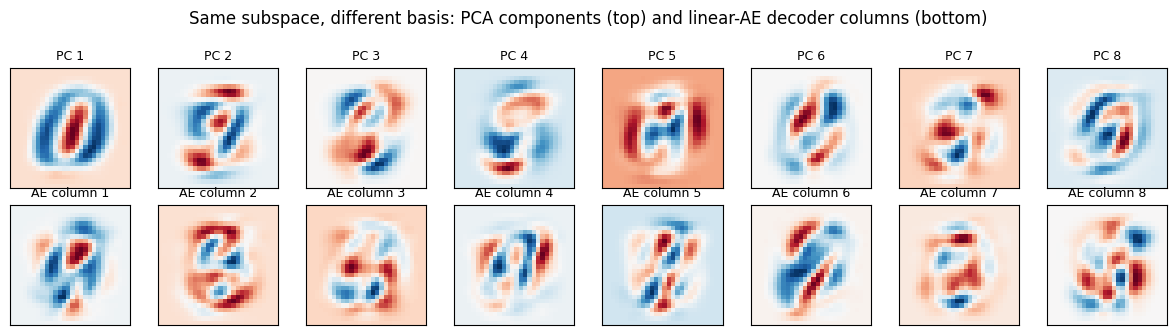

In [13]:
# Nonlinear AE with the same k: no subspace to compare, so compare the error it reaches on held-out digits.
with torch.no_grad():
    Xte64 = Xc_te.cpu().double()
    err_pca_te = float(((Xte64 - Xte64 @ P_pca) ** 2).sum(1).mean())
    err_lin_te = per_image_err(lin_ae, Xc_te)
net16, _ = train_ae(k=K_PCA, epochs=12)
with torch.no_grad():
    err_relu_te = ((net16(Xte) - Xte) ** 2).sum(1).mean().item()
print(f'held-out per-image error, k = {K_PCA}:   PCA {err_pca_te:.3f}   linear AE {err_lin_te:.3f}   ReLU AE (12 epochs) {err_relu_te:.3f}')
print('the nonlinear AE is not bound by Eckart-Young: with a curved manifold it can do better than any subspace')

fig, ax = plt.subplots(2, 8, figsize=(12, 3.3))
for j in range(8):
    ax[0, j].imshow(to_np(V_k[:, j]).reshape(28, 28), cmap='RdBu_r'); ax[0, j].set_title(f'PC {j + 1}', fontsize=9)
    ax[1, j].imshow(to_np(W[:, j]).reshape(28, 28), cmap='RdBu_r'); ax[1, j].set_title(f'AE column {j + 1}', fontsize=9)
    for a_ in ax[:, j]: a_.set_xticks([]); a_.set_yticks([])
fig.suptitle('Same subspace, different basis: PCA components (top) and linear-AE decoder columns (bottom)', y=1.0)
plt.tight_layout(); plt.show()

## 5. Seq2seq and the information bottleneck

Back to the NMT model. The slides draw the sequence-to-sequence architecture (*Sutskever et al., NeurIPS
2014*; *Cho et al., EMNLP 2014*) and the image captioning model (a CNN encoder, an RNN decoder), and then
ask "what is the problem?":

> "A hidden state at time step $t$ ($h_t$) is a compressed form of all previous inputs
> $(x_1, x_2, \dots, x_t)$. But what if input is very long? Can $h_T$ encode all information without
> forgetting? **Information bottleneck!**"

> "Can we guarantee that words seen at earlier input time steps be reproduced in later time steps of output?"

The evidence in the slides is the **BLEU score** (Bilingual Evaluation Understudy, a metric for machine
translated text also used for captioning and VQA) plotted against sentence length: it rises, then
**degrades** for long sentences instead of saturating. Translation data is too big for this notebook, so the
same experiment runs on a task where the failure is unmistakable: **reverse a sequence of digits**. The
input $x_1 \dots x_L$ must come out as $x_L \dots x_1$, so the decoder's *first* output is the encoder's
*last* input and its last output is the encoder's first input, which is exactly the "words seen at earlier
input time steps" that the slide worries about. Lengths 1 to 12 appear in training; lengths 13 to 16 are
held out to see what happens beyond the training range.

In [14]:
V = 10                                   # digit vocabulary 0..9
PAD, SOS = V, V + 1                      # two special tokens
N_TOK = V + 2
L_TRAIN_MAX, L_TEST_MAX = 12, 16


def make_batch(n, L_min, L_max, gen):
    """n sequences with lengths uniform in [L_min, L_max]; target = input reversed; padded with PAD."""
    lens = torch.randint(L_min, L_max + 1, (n,), generator=gen)
    L = int(lens.max())
    x = torch.full((n, L), PAD); y = torch.full((n, L), PAD)
    for i, Li in enumerate(lens.tolist()):
        s = torch.randint(0, V, (Li,), generator=gen)
        x[i, :Li] = s; y[i, :Li] = s.flip(0)
    return x.to(device), y.to(device), lens.to(device)


def fmt(seq):
    """Tokens -> string, dropping PAD."""
    return ' '.join(str(int(t)) for t in seq if int(t) < V)


gen_demo = torch.Generator().manual_seed(0)
x_demo, y_demo, len_demo = make_batch(3, 3, 8, gen_demo)
for i in range(3):
    print(f'  input  [{fmt(x_demo[i]):>23}]   target  [{fmt(y_demo[i]):>23}]   (length {int(len_demo[i])})')

  input  [              0 3 9 7 3]   target  [              3 7 9 3 0]   (length 5)
  input  [            7 3 1 6 6 9]   target  [            9 6 6 1 3 7]   (length 6)
  input  [        8 6 6 8 4 3 6 9]   target  [        9 6 3 4 8 6 6 8]   (length 8)


### 5.a The model without attention

The decoder follows the slide's recursion $s_t = f(s_{t-1}, y_{t-1})$ with $s_0 = h_T$, and an output
layer $p(y_t) = g(s_t)$ turns the state into token probabilities. It is trained with **teacher forcing**:
during training the true previous token $y_{t-1}$ is fed in, and the loss is the cross-entropy of each
predicted token. At test time the decoder feeds its own greedy prediction back in. The `context` method is
a placeholder that returns nothing; Section 6 fills it in. Everything else (the GRU cell, the output layer,
the training loop, the decoding loop) stays the same for both models, so whatever changes in the results
is due to attention alone.

In [15]:
class Decoder(nn.Module):
    """s_t = f(s_{t-1}, y_{t-1}), s_0 = h_T. Without attention, s_0 is the decoder's only link to the input."""
    def __init__(self, n_tokens, d, ctx_dim=0):
        super().__init__()
        self.emb = nn.Embedding(n_tokens, d)
        self.cell = nn.GRUCell(d + ctx_dim, d)
        self.out = nn.Linear(d + ctx_dim, n_tokens)     # p(y_t) = g(y_{t-1}, s_t, c_t): the output reads [s_t ; c_t]
        self.alpha_fn = None                            # optional post-processing of attention weights (Section 10)

    def context(self, s_prev, H, mask):
        """Returns (c_t, alpha_t). No attention: nothing to add."""
        return None, None

    def step(self, y_prev, s_prev, H, mask):
        e = self.emb(y_prev)
        c, alpha = self.context(s_prev, H, mask)
        if c is not None:
            e = torch.cat([e, c], dim=-1)               # s_t = f(s_{t-1}, y_{t-1}, c_t)
        s = self.cell(e, s_prev)
        o = s if c is None else torch.cat([s, c], dim=-1)
        return self.out(o), s, alpha

    def forward(self, H, h_T, mask, y_in):
        """Teacher forcing: y_in holds SOS followed by the true targets."""
        s, logits, alphas = h_T, [], []
        for t in range(y_in.shape[1]):
            lg, s, a = self.step(y_in[:, t], s, H, mask)
            logits.append(lg); alphas.append(a)
        return torch.stack(logits, 1), (torch.stack(alphas, 1) if alphas[0] is not None else None)


def train_seq2seq(make_decoder, steps=1500, d=32, lr=3e-3, batch=64, seed=0, log_every=250):
    """Train encoder + decoder on the reverse task with lengths 1..L_TRAIN_MAX. Returns (enc, dec)."""
    set_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    enc, dec = GRUEncoder(N_TOK, d).to(device), make_decoder(d).to(device)
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=lr)
    t0 = time.time()
    for it in range(1, steps + 1):
        x, y, lens = make_batch(batch, 1, L_TRAIN_MAX, gen)
        H, h_T = enc(x, lens)
        mask = x != PAD
        sos = torch.full((batch, 1), SOS, device=device)
        y_in = torch.cat([sos, y[:, :-1]], dim=1)
        logits, _ = dec(H, h_T, mask, y_in)
        loss = F.cross_entropy(logits.reshape(-1, N_TOK), y.reshape(-1), ignore_index=PAD)
        opt.zero_grad(); loss.backward(); opt.step()
        if log_every and (it % log_every == 0 or it == 1):
            print(f'  step {it:4d}  loss {loss.item():.3f}')
    print(f'  trained in {time.time() - t0:.1f} s  ({count_params(enc) + count_params(dec)} parameters)')
    return enc, dec


@torch.no_grad()
def greedy_decode(enc, dec, x, L):
    """Feed the decoder its own predictions for L steps. Returns tokens (B, L) and alphas (B, L, T) or None."""
    mask = x != PAD
    H, h_T = enc(x, mask.sum(1))
    s = h_T
    tok = torch.full((x.shape[0],), SOS, device=device)
    outs, alphas = [], []
    for t in range(L):
        lg, s, a = dec.step(tok, s, H, mask)
        tok = lg.argmax(-1)
        outs.append(tok); alphas.append(a)
    return torch.stack(outs, 1), (torch.stack(alphas, 1) if alphas[0] is not None else None)


@torch.no_grad()
def accuracy_by_length(enc, dec, lengths=range(1, L_TEST_MAX + 1), n=300, seed=1):
    """Fraction of sequences reversed perfectly, per input length (fixed test draw)."""
    gen = torch.Generator().manual_seed(seed)
    acc = {}
    for L in lengths:
        x, y, _ = make_batch(n, L, L, gen)
        pred, _ = greedy_decode(enc, dec, x, L)
        acc[L] = (pred == y).all(1).float().mean().item()
    return acc


print('seq2seq WITHOUT attention:')
enc0, dec0 = train_seq2seq(lambda d: Decoder(N_TOK, d))
acc0 = accuracy_by_length(enc0, dec0)
print('\n  length   ' + ' '.join(f'{L:4d}' for L in acc0))
print('  accuracy ' + ' '.join(f'{acc0[L]:4.2f}' for L in acc0))

seq2seq WITHOUT attention:
  step    1  loss 2.476


  step  250  loss 1.006


  step  500  loss 0.557


  step  750  loss 0.550


  step 1000  loss 0.505


  step 1250  loss 0.414


  step 1500  loss 0.454
  trained in 5.1 s  (12300 parameters)

  length      1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16
  accuracy 1.00 1.00 0.98 0.88 0.70 0.45 0.33 0.21 0.14 0.03 0.02 0.00 0.00 0.00 0.00 0.00


The curve has the shape of the slide's BLEU plot. Short inputs are reversed perfectly, then accuracy
degrades with length until the model gets essentially nothing right, well inside the training range.
The model is not short of parameters or of training data (every batch is fresh): what it is short of is
room in the single 32-dimensional context vector for a growing number of digits that all have to be
reproduced in order.

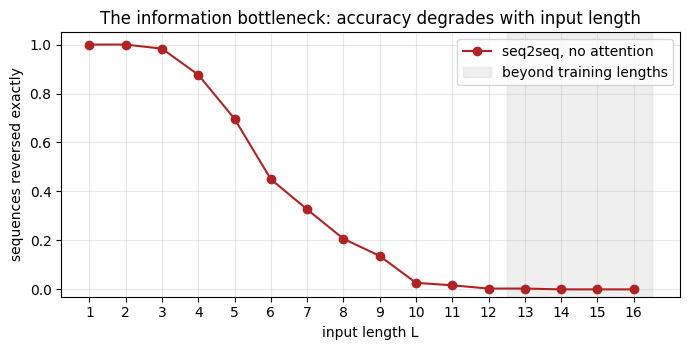

In [16]:
Ls = list(acc0.keys())
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(Ls, [acc0[L] for L in Ls], 'o-', color='firebrick', label='seq2seq, no attention')
ax.axvspan(L_TRAIN_MAX + 0.5, L_TEST_MAX + 0.5, color='gray', alpha=0.12, label='beyond training lengths')
ax.set_xlabel('input length L'); ax.set_ylabel('sequences reversed exactly'); ax.set_ylim(-0.03, 1.05)
ax.set_xticks(Ls); ax.grid(alpha=0.3); ax.legend(loc='upper right')
ax.set_title('The information bottleneck: accuracy degrades with input length')
plt.tight_layout(); plt.show()

### 5.b Why a fixed-length vector must fail

The failure is not specific to GRUs. Any fixed-length summary has finite capacity: pack more independent
items into it and retrieval degrades, however cleverly the encoder is built. The cell below packs $n$ random
unit vectors into a single $d$-dimensional sum $c = \sum_i v_i$ and then queries the summary: given a probe
that is either one of the stored items or a fresh random unit vector, can a dot product with $c$ tell the
two apart? For a stored item $v_k$, $v_k^\top c = 1 + \sum_{i \ne k} v_k^\top v_i$, a signal of size 1 plus
$n - 1$ cross terms of standard deviation $1/\sqrt d$, so the noise grows like $\sqrt{n / d}$ and the test
"$v^\top c > 1/2$" is reliable only while $n$ is small compared with $d$. With $d = 32$ the accuracy is
essentially perfect for two items and drifts towards a coin toss as $n$ grows past $d$, the same regime in
which the seq2seq model above collapsed.

In [17]:
# A fixed-length vector has finite capacity. Pack more independent items into it and
# retrieval gets worse, however the encoder is built.
d = 32                                        # context vector width

def presence_accuracy(n_items, d=d, trials=2000, seed=0):
    """Store n random unit vectors as their sum c. Probe c with a stored item (half the trials) or a fresh
    random unit vector (the other half) and answer 'stored' if probe . c > 1/2. Returns the accuracy."""
    g = torch.Generator().manual_seed(seed)
    items = torch.randn(trials, n_items, d, generator=g)
    items = items / items.norm(dim=-1, keepdim=True)
    context = items.sum(1)                                        # (trials, d): one summary per trial
    stored = items[:, 0]                                          # a probe that IS in the summary
    fresh = torch.randn(trials, d, generator=g); fresh = fresh / fresh.norm(dim=-1, keepdim=True)
    is_stored = torch.arange(trials) % 2 == 0                     # half the probes are stored, half are fresh
    probe = torch.where(is_stored[:, None], stored, fresh)
    decision = (probe * context).sum(-1) > 0.5
    return (decision == is_stored).float().mean().item()

print(f'context vector width d = {d}\n')
print('  items n   noise std sqrt(n/d)   stored-or-fresh accuracy')
presence = {}
for n in (2, 4, 8, 16, 32, 64, 128, 256):
    presence[n] = presence_accuracy(n)
    print(f'    {n:4d}         {math.sqrt(n / d):5.2f}                 {100 * presence[n]:5.1f}%')
assert presence[2] > 0.97, 'two items in a 32-d summary should be retrievable'
assert presence[256] < 0.7 and presence[256] < presence[8] < presence[2], 'accuracy must fall as n / d grows'
print('\ncapacity is finite: the more the encoder must remember, the less survives (chance is 50%)')

context vector width d = 32

  items n   noise std sqrt(n/d)   stored-or-fresh accuracy
       2          0.25                  98.5%
       4          0.35                  93.5%
       8          0.50                  85.0%
      16          0.71                  78.0%
      32          1.00                  68.3%
      64          1.41                  65.2%


     128          2.00                  60.7%


     256          2.83                  56.7%

capacity is finite: the more the encoder must remember, the less survives (chance is 50%)


## 6. The attention mechanism

The slide's intuition is a photograph and a question about it: to answer "how many people are in the
image?" you first identify the artifacts in the scene and then **pay attention to the relevant ones**.
Translation is the same: to produce the next French word you look at the relevant English words, not at a
summary of the whole sentence.

Formally, with encoder states $h_j$ at time-step $j$ and decoder state $s_t$ at time-step $t$:

> "Attention mechanism creates shortcut connections between context vector ($c_t$) and the entire source
> input ($X$)."

The decoder state now depends on a context vector that is recomputed at **every** step,

$$s_t = f(s_{t-1},\, y_{t-1},\, c_t), \qquad c_t = \sum_{j=1}^{T} \alpha_{t,j}\, h_j,$$

and $\alpha_{t,j}$ measures the alignment between the previous decoder state and each encoder state,
normalised over the source positions:

$$\alpha_{t,j} = \frac{\exp\big(score(s_{t-1}, h_j)\big)}{\sum_{j'=1}^{T} \exp\big(score(s_{t-1}, h_{j'})\big)}.$$

Nothing is summarised once and for all any more: all $T$ encoder states stay available, and the decoder
chooses, softly, which of them to read at each step. In code the whole mechanism is three lines.

In [18]:
# Attention in three lines (scores, softmax, weighted sum), plus the two properties that make it work.
T, dh = 7, 16                                 # source length, hidden width

H = torch.randn(T, dh, device=device)         # encoder states h_1 ... h_T
s_prev = torch.randn(dh, device=device)       # decoder state s_{t-1}

scores = H @ s_prev                           # score(s_{t-1}, h_j) for every j
alpha = torch.softmax(scores, dim=0)          # normalise over source positions
c_t = (alpha[:, None] * H).sum(0)             # c_t = sum_j alpha_{t,j} h_j

assert alpha.shape == (T,) and c_t.shape == (dh,)
assert torch.allclose(alpha.sum(), torch.tensor(1.0, device=device)), 'attention weights must sum to 1'
assert (alpha >= 0).all(), 'attention weights must be non-negative'
assert torch.allclose(c_t, alpha @ H, atol=1e-6), 'the weighted sum is just a matrix product'

print(f'  encoder states H {tuple(H.shape)},  alpha {tuple(alpha.shape)},  context {tuple(c_t.shape)}')
print(f'  alpha sums to {alpha.sum():.6f}  (a distribution over the {T} source positions)')
print(f'  the context vector has the same width as one encoder state: {c_t.shape[0]} == {dh}')
print(f'\n  alpha = {[round(v, 3) for v in alpha.tolist()]}')

  encoder states H (7, 16),  alpha (7,),  context (16,)
  alpha sums to 1.000000  (a distribution over the 7 source positions)
  the context vector has the same width as one encoder state: 16 == 16

  alpha = [0.0, 0.0, 0.0, 0.992, 0.0, 0.006, 0.002]


### 6.a The same decoder, with attention

`AttnDecoder` subclasses the decoder of Section 5 and overrides only `context`: it scores $s_{t-1}$ against
every $h_j$, masks the padded positions, takes the softmax and returns the weighted sum. The GRU cell's input
grows from $d$ to $2d$ to make room for $c_t$, and the output layer reads $[s_t; c_t]$, which is Bahdanau's
$p(y_t) = g(y_{t-1}, s_t, c_t)$. The `score` argument selects the alignment score function; this section
trains the plain **dot product** $s_{t-1}^\top h_j$, and Section 7 covers the rest.

In [19]:
class AttnDecoder(Decoder):
    """The Section 5 decoder plus one method: c_t = sum_j alpha_tj h_j with alpha = softmax(score(s_{t-1}, h_j))."""
    def __init__(self, n_tokens, d, score='dot', k_add=32):
        super().__init__(n_tokens, d, ctx_dim=d)
        self.score = score
        if score == 'general':
            self.Wa = nn.Linear(d, d, bias=False)                 # s^T W_a h
        elif score == 'additive':
            self.Wa = nn.Linear(2 * d, k_add, bias=False)         # v_a^T tanh(W_a [s; h])
            self.va = nn.Linear(k_add, 1, bias=False)

    def scores(self, s_prev, H):
        """score(s_{t-1}, h_j) for every j: (B, d) x (B, T, d) -> (B, T)."""
        if self.score == 'dot':
            return torch.einsum('bd,btd->bt', s_prev, H)
        if self.score == 'scaled':
            return torch.einsum('bd,btd->bt', s_prev, H) / math.sqrt(H.shape[-1])
        if self.score == 'general':
            return torch.einsum('bd,btd->bt', self.Wa(s_prev), H)
        if self.score == 'additive':
            pair = torch.cat([s_prev[:, None, :].expand(-1, H.shape[1], -1), H], dim=-1)
            return self.va(torch.tanh(self.Wa(pair))).squeeze(-1)
        raise ValueError(self.score)

    def context(self, s_prev, H, mask):
        sc = self.scores(s_prev, H).masked_fill(~mask, -1e9)      # padded positions get zero weight
        alpha = torch.softmax(sc, dim=-1)
        if self.alpha_fn is not None:                             # hard / local variants, Section 10
            alpha = self.alpha_fn(alpha)
        c = torch.einsum('bt,btd->bd', alpha, H)
        return c, alpha


print('seq2seq WITH dot-product attention:')
enc1, dec1 = train_seq2seq(lambda d: AttnDecoder(N_TOK, d, score='dot'))
acc1 = accuracy_by_length(enc1, dec1)
print('\n  length        ' + ' '.join(f'{L:4d}' for L in acc1))
print('  no attention  ' + ' '.join(f'{acc0[L]:4.2f}' for L in acc0))
print('  dot attention ' + ' '.join(f'{acc1[L]:4.2f}' for L in acc1))
assert acc1[L_TRAIN_MAX] > acc0[L_TRAIN_MAX] + 0.3, 'attention should lift accuracy at the longest training length'

seq2seq WITH dot-product attention:
  step    1  loss 2.466


  step  250  loss 0.301


  step  500  loss 0.101


  step  750  loss 0.062


  step 1000  loss 0.022


  step 1250  loss 0.205


  step 1500  loss 0.018
  trained in 9.1 s  (15756 parameters)

  length           1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16
  no attention  1.00 1.00 0.98 0.88 0.70 0.45 0.33 0.21 0.14 0.03 0.02 0.00 0.00 0.00 0.00 0.00
  dot attention 1.00 1.00 0.96 0.95 0.95 0.91 0.96 0.97 0.95 0.98 0.96 0.91 0.82 0.65 0.47 0.40


Same encoder, same GRU cell, same number of training steps: the attention model keeps reversing sequences
long after the plain model has collapsed, and it degrades gracefully instead of falling off a cliff, also
on the lengths it never saw in training. The bottleneck is gone because the decoder no longer needs
$h_T$ to remember everything; it goes back and reads $h_j$ when it needs $x_j$.

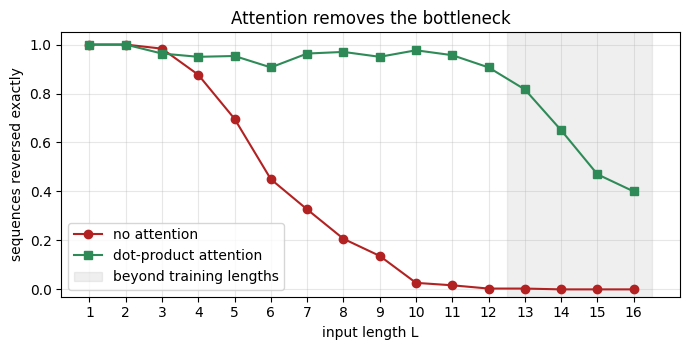

In [20]:
# Static sweep: accuracy versus length for both models, plus one decoded example per length.
gen_ex = torch.Generator().manual_seed(7)
examples = {}
for L in Ls:
    x, y, _ = make_batch(1, L, L, gen_ex)
    p0, _ = greedy_decode(enc0, dec0, x, L)
    p1, _ = greedy_decode(enc1, dec1, x, L)
    examples[L] = dict(x=fmt(x[0]), y=fmt(y[0]), p0=fmt(p0[0]), p1=fmt(p1[0]),
                       ok0=bool((p0[0] == y[0]).all()), ok1=bool((p1[0] == y[0]).all()))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(Ls, [acc0[L] for L in Ls], 'o-', color='firebrick', label='no attention')
ax.plot(Ls, [acc1[L] for L in Ls], 's-', color='seagreen', label='dot-product attention')
ax.axvspan(L_TRAIN_MAX + 0.5, L_TEST_MAX + 0.5, color='gray', alpha=0.12, label='beyond training lengths')
ax.set_xlabel('input length L'); ax.set_ylabel('sequences reversed exactly'); ax.set_ylim(-0.03, 1.05)
ax.set_xticks(Ls); ax.grid(alpha=0.3); ax.legend(loc='lower left')
ax.set_title('Attention removes the bottleneck')
plt.tight_layout(); plt.show()

### Widget 3: input length versus accuracy

Drag `L`. The marker moves along both curves and the text shows one held-out sequence of that length with
the two models' outputs. From $L = 6$ onwards the plain model's errors are transpositions: the first outputs
(the encoder's most recent inputs) survive, digits further along get swapped with a neighbour, and by
$L = 10$ its output is barely related to the input. The examples were decoded above, so the slider only
indexes them.

In [21]:
def show_length(L=8):
    ex = examples[L]
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.plot(Ls, [acc0[k] for k in Ls], 'o-', color='firebrick', label='no attention', alpha=0.6)
    ax.plot(Ls, [acc1[k] for k in Ls], 's-', color='seagreen', label='dot attention', alpha=0.6)
    ax.plot([L], [acc0[L]], 'o', color='firebrick', ms=12); ax.plot([L], [acc1[L]], 's', color='seagreen', ms=12)
    ax.axvline(L, color='k', lw=0.6, ls='--')
    ax.set_xlabel('input length L'); ax.set_ylabel('exact-match accuracy'); ax.set_ylim(-0.03, 1.05)
    ax.set_xticks(Ls); ax.grid(alpha=0.3); ax.legend(loc='lower left')
    ax.set_title(f'L = {L}:  no attention {acc0[L]:.2f}   dot attention {acc1[L]:.2f}')
    plt.tight_layout(); plt.show()
    print(f'  input          {ex["x"]}')
    print(f'  target         {ex["y"]}')
    print(f'  no attention   {ex["p0"]}   {"correct" if ex["ok0"] else "wrong"}')
    print(f'  dot attention  {ex["p1"]}   {"correct" if ex["ok1"] else "wrong"}')

interact(show_length, L=IntSlider(min=1, max=L_TEST_MAX, step=1, value=8, description='L'));

interactive(children=(IntSlider(value=8, description='L', max=16, min=1), Output()), _dom_classes=('widget-int…

### 6.b Alignment: where the decoder looks at each step

The weights $\alpha_{t,j}$ form an $L_{\text{out}} \times L_{\text{in}}$ **alignment matrix**: row $t$ is the
distribution the decoder used when it produced output $t$. For the reverse task the correct alignment is
known exactly, output $t$ needs input $L - 1 - t$, so one would expect an anti-diagonal. What the trained
model shows is a **shifted anti-diagonal**: the peak of row $t$ sits on $L - 1 - t$ or one step to its right.
Both positions carry the token. The encoder is bidirectional, and its backward state at $j + 1$ has just
consumed $x_j$, so the decoder can read $x_j$ from $h_{j+1}$ as easily as from $h_j$; the loss does not
distinguish the two, and gradient descent settled on a mixture. The model was never told any of this; the
pattern below was discovered from the reversal loss alone.

input  9 0 7 3 7 1 0 7 7 2
output 2 7 7 0 1 7 3 7 0 9   (correct)
peak position per step [9, 8, 8, 7, 6, 5, 4, 3, 2, 1]   (exact anti-diagonal would be [9, 8, 7, 6, 5, 4, 3, 2, 1, 0])
mean weight on the correct source position: 0.248, within one position of it: 0.976  (uniform attention would give 0.100 and 0.280)


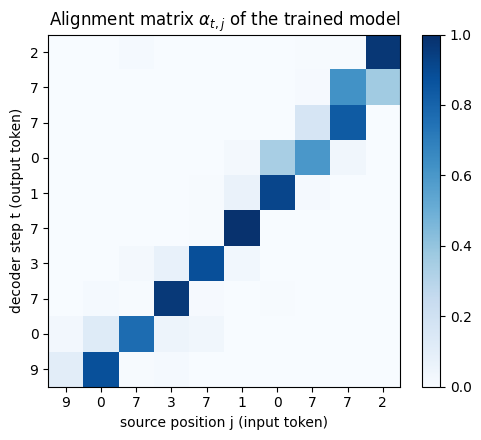

In [22]:
x_al, y_al, _ = make_batch(1, 10, 10, torch.Generator().manual_seed(11))
pred_al, alpha_al = greedy_decode(enc1, dec1, x_al, 10)
A_al = to_np(alpha_al[0])                                   # (L_out, L_in)
src_tok = [str(int(t)) for t in x_al[0]]
out_tok = [str(int(t)) for t in pred_al[0]]
on_target = float(np.mean([A_al[t, 9 - t] for t in range(10)]))
within_one = float(np.mean([A_al[t, max(8 - t, 0):min(10 - t, 9) + 1].sum() for t in range(10)]))
peaks = [int(A_al[t].argmax()) for t in range(10)]
print(f'input  {fmt(x_al[0])}\noutput {fmt(pred_al[0])}   ({"correct" if (pred_al[0] == y_al[0]).all() else "wrong"})')
print(f'peak position per step {peaks}   (exact anti-diagonal would be {[9 - t for t in range(10)]})')
print(f'mean weight on the correct source position: {on_target:.3f}, within one position of it: {within_one:.3f}  '
      f'(uniform attention would give 0.100 and 0.280)')

fig, ax = plt.subplots(figsize=(5.2, 4.5))
im = ax.imshow(A_al, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(src_tok); ax.set_xlabel('source position j (input token)')
ax.set_yticks(range(10)); ax.set_yticklabels(out_tok); ax.set_ylabel('decoder step t (output token)')
ax.set_title('Alignment matrix $\\alpha_{t,j}$ of the trained model')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

### Widget 4: the attention distribution at each decoder step

Drag `t` through the decoder steps. The bar chart is row $t$ of the matrix above: the tallest bar is at,
or one step to the right of, the source token that appears in the output, and the dashed line marks the
token's own position $L - 1 - t$. Watch the peak march from the last input position to the first.

In [23]:
def show_step(t=0):
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={'width_ratios': [2, 1.2]})
    ax[0].bar(range(10), A_al[t], color='steelblue')
    ax[0].axvline(9 - t, color='firebrick', ls='--', label='correct position L-1-t')
    ax[0].set_xticks(range(10)); ax[0].set_xticklabels([f'{j}\n"{s}"' for j, s in enumerate(src_tok)])
    ax[0].set_ylim(0, 1); ax[0].set_ylabel('$\\alpha_{t,j}$'); ax[0].set_xlabel('source position j (token)')
    ax[0].set_title(f'step t = {t}: output "{out_tok[t]}", peak at j = {int(A_al[t].argmax())} '
                    f'(weight {A_al[t].max():.2f})'); ax[0].legend(loc='upper center')
    ax[1].imshow(A_al, cmap='Blues', vmin=0, vmax=1)
    ax[1].axhline(t, color='orange', lw=2)
    ax[1].set_xticks(range(10)); ax[1].set_yticks(range(10)); ax[1].set_title('row t of the alignment matrix')
    plt.tight_layout(); plt.show()

interact(show_step, t=IntSlider(min=0, max=9, step=1, value=0, description='t'));

interactive(children=(IntSlider(value=0, description='t', max=9), Output()), _dom_classes=('widget-interact',)…

## 7. Alignment score functions

The slides tabulate six choices for $score$ (credit: Lilian Weng, *Attention? Attention!*):

| Name | Score function | Paper |
|---|---|---|
| Content-based | $\operatorname{cosine}(s_t, h_i)$ | Graves et al., 2014 |
| Additive | $v_a^{\top}\tanh\big(W_a[s_t; h_i]\big)$ | Bahdanau et al., ICLR 2015 |
| Location-based | $\alpha_{t,j} = \operatorname{softmax}(W_a s_t)$ | Luong et al., EMNLP 2015 |
| General | $s_t^{\top} W_a h_i$ | Luong et al., EMNLP 2015 |
| Dot-product | $s_t^{\top} h_i$ | Luong et al., EMNLP 2015 |
| Scaled dot-product | $s_t^{\top} h_i / \sqrt{n}$ | Vaswani et al., NeurIPS 2017 |

Several of these are the same function in disguise, which is worth establishing rather than taking on
trust. The cell below implements all six on the random states of Section 6 and checks the relationships.

In [24]:
# Implement all six, then check the relationships between them.
k = 12                                        # additive attention's inner width

Wa_gen = torch.randn(dh, dh, device=device)
Wa_add = torch.randn(k, 2 * dh, device=device)
va_add = torch.randn(k, device=device)
Wa_loc = torch.randn(T, dh, device=device)

def score_dot(s, H):      return H @ s
def score_scaled(s, H):   return (H @ s) / np.sqrt(dh)
def score_general(s, H):  return H @ (Wa_gen @ s)
def score_cosine(s, H):   return F.cosine_similarity(H, s[None, :].expand_as(H), dim=1)
def score_additive(s, H):
    pair = torch.cat([s[None, :].expand(H.shape[0], -1), H], dim=1)   # [s_t ; h_i]
    return torch.tanh(pair @ Wa_add.T) @ va_add
def alpha_location(s, H): return torch.softmax(Wa_loc @ s, dim=0)     # same signature, but H is ignored

# 1. Dot-product is general attention with W_a = I.
Wa_gen_backup = Wa_gen.clone()
Wa_gen = torch.eye(dh, device=device)
assert torch.allclose(score_general(s_prev, H), score_dot(s_prev, H), atol=1e-5)
Wa_gen = Wa_gen_backup

# 2. Content-based (cosine) is the dot product on L2-normalised vectors.
Hn = H / H.norm(dim=1, keepdim=True)
sn = s_prev / s_prev.norm()
assert torch.allclose(score_cosine(s_prev, H), Hn @ sn, atol=1e-5)

# 3. Scaling changes the softmax temperature but never the argmax.
assert score_dot(s_prev, H).argmax() == score_scaled(s_prev, H).argmax()

# 4. Location-based attention does not look at H at all: swap the encoder states for fresh random ones and
#    the location weights do not move, while every content-based score does.
H_other = torch.randn(T, dh, device=device)
assert torch.allclose(alpha_location(s_prev, H), alpha_location(s_prev, H_other)), 'location weights must ignore H'
assert not torch.allclose(score_dot(s_prev, H), score_dot(s_prev, H_other)), 'dot-product scores must depend on H'
assert not torch.allclose(score_additive(s_prev, H), score_additive(s_prev, H_other)), 'additive scores must depend on H'

# 5. Additive attention needs its tanh. To first order (small inputs, tanh(z) ~ z) the score is
#    v_a^T W_a [s; h] = f(s) + g(h): the f(s) term is the same for every j and cancels in the softmax,
#    so without the nonlinearity the weights would not depend on the decoder state at all.
Wa_s, Wa_h = Wa_add[:, :dh], Wa_add[:, dh:]
small = 1e-4
lin = (va_add @ Wa_s) @ (small * s_prev) + H @ (Wa_h.T @ va_add) * small
assert torch.allclose(score_additive(small * s_prev, small * H), lin, atol=1e-7)
s_other = torch.randn(dh, device=device)
lin_other = (va_add @ Wa_s) @ (small * s_other) + H @ (Wa_h.T @ va_add) * small
assert torch.allclose(torch.softmax(lin, 0), torch.softmax(lin_other, 0), atol=1e-6), 'linearised weights ignore s'

print('  dot-product  == general with W_a = I           ok')
print('  content-based== dot-product on normalised rows ok')
print('  scaled       == dot-product up to temperature  ok (same argmax)')
print('  location     == independent of H entirely      ok')
print('  additive     == f(s) + g(h) without the tanh, so the tanh is what couples s and h  ok')

  dot-product  == general with W_a = I           ok
  content-based== dot-product on normalised rows ok
  scaled       == dot-product up to temperature  ok (same argmax)
  location     == independent of H entirely      ok
  additive     == f(s) + g(h) without the tanh, so the tanh is what couples s and h  ok


In [25]:
# The six differ sharply in how many parameters they cost.
counts = {
    'dot-product':        0,
    'scaled dot-product': 0,
    'content-based':      0,
    'general':            dh * dh,
    'additive':           Wa_add.numel() + va_add.numel(),
    'location-based':     Wa_loc.numel(),
}
assert counts['general'] == dh ** 2
assert counts['additive'] == 2 * dh * k + k

print(f'  with hidden width d = {dh} and additive inner width k = {k}:\n')
for name, n in sorted(counts.items(), key=lambda kv: kv[1]):
    print(f'    {name:20s} {n:5d} parameters')
print(f'\n  additive costs 2dk + k = 2*{dh}*{k} + {k} = {counts["additive"]}')
print('  the dot-product family is free, which is why it scales')

  with hidden width d = 16 and additive inner width k = 12:

    dot-product              0 parameters
    scaled dot-product       0 parameters
    content-based            0 parameters
    location-based         112 parameters
    general                256 parameters
    additive               396 parameters

  additive costs 2dk + k = 2*16*12 + 12 = 396
  the dot-product family is free, which is why it scales


### 7.a Does the choice matter? Additive versus dot-product, trained

Bahdanau's original model used the additive score; Luong's comparison found dot-product and general
attention competitive and cheaper. The cell trains the additive variant with everything else unchanged and
compares the two on the same held-out lengths. Both remove the bottleneck; which one wins by a few points
is a matter of the task and the budget, not of principle.

In [26]:
print('seq2seq WITH additive attention:')
enc2, dec2 = train_seq2seq(lambda d: AttnDecoder(N_TOK, d, score='additive'))
acc2 = accuracy_by_length(enc2, dec2)

print('\n  length             ' + ' '.join(f'{L:4d}' for L in (4, 6, 8, 10, 12, 14, 16)))
for name, acc in (('no attention', acc0), ('dot-product', acc1), ('additive', acc2)):
    print(f'  {name:18s} ' + ' '.join(f'{acc[L]:4.2f}' for L in (4, 6, 8, 10, 12, 14, 16)))
mean_tr = lambda acc: np.mean([acc[L] for L in range(1, L_TRAIN_MAX + 1)])
print(f'\n  mean accuracy over training lengths 1..{L_TRAIN_MAX}:  no attention {mean_tr(acc0):.3f}   '
      f'dot {mean_tr(acc1):.3f}   additive {mean_tr(acc2):.3f}')
print(f'  attention parameters: dot 0, additive {count_params(dec2.Wa) + count_params(dec2.va)}')

seq2seq WITH additive attention:
  step    1  loss 2.468


  step  250  loss 0.201


  step  500  loss 0.024


  step  750  loss 0.012


  step 1000  loss 0.002


  step 1250  loss 0.011


  step 1500  loss 0.002
  trained in 9.9 s  (17836 parameters)

  length                4    6    8   10   12   14   16
  no attention       0.88 0.45 0.21 0.03 0.00 0.00 0.00
  dot-product        0.95 0.91 0.97 0.98 0.91 0.65 0.40
  additive           0.93 0.96 0.98 0.98 0.99 0.74 0.07

  mean accuracy over training lengths 1..12:  no attention 0.477   dot 0.958   additive 0.963
  attention parameters: dot 0, additive 2080


### Widget 5: score functions and sharpness

Pick a `score` function and drag `beta`, a sharpness (an inverse temperature) multiplied into the scores
before the softmax.
All five produce a valid distribution over the seven source positions of Section 6; they differ in how
peaked it is. Cosine scores live in $[-1, 1]$ and give a flat distribution unless `beta` is large, which
is exactly why the scaled dot-product divides by $\sqrt n$: it keeps the scores in a range where the softmax
is neither flat nor saturated as the width grows.

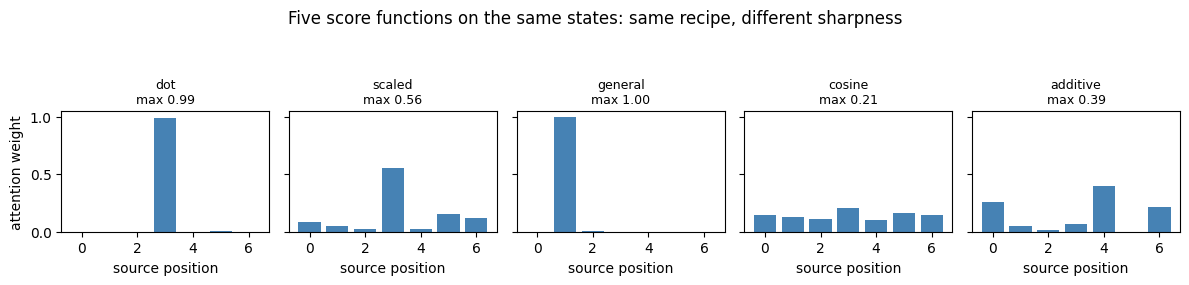

In [27]:
# Static sweep over the five score functions at beta = 1 on the same encoder states.
score_fns = {'dot': score_dot, 'scaled': score_scaled, 'general': score_general,
             'cosine': score_cosine, 'additive': score_additive}
fig, ax = plt.subplots(1, 5, figsize=(12, 2.6), sharey=True)
for a_, (name, fn) in zip(ax, score_fns.items()):
    w = torch.softmax(fn(s_prev, H), dim=0)
    a_.bar(range(T), to_np(w), color='steelblue')
    a_.set_title(f'{name}\nmax {w.max():.2f}', fontsize=9); a_.set_xlabel('source position')
ax[0].set_ylabel('attention weight')
fig.suptitle('Five score functions on the same states: same recipe, different sharpness', y=1.08)
plt.tight_layout(); plt.show()

Now the same comparison under your control: pick a score function and drag `beta` to sharpen or flatten it.

In [28]:
# Live: compare score functions and sharpness on the same encoder states.
def show(score='dot', beta=1.0):
    fn = score_fns[score]
    w = torch.softmax(beta * fn(s_prev, H), dim=0)
    ent = -(w * w.log()).sum()
    fig, a_ = plt.subplots(figsize=(7, 3))
    a_.bar(range(T), to_np(w), color='steelblue')
    a_.set_xlabel('source position'); a_.set_ylabel('attention weight'); a_.set_ylim(0, 1)
    a_.set_title(f'{score} attention, $\\beta$={beta:.1f}   entropy {ent:.2f} nats   max {w.max():.2f}')
    plt.tight_layout(); plt.show()

interact(show, score=Dropdown(options=list(score_fns), value='dot'),
               beta=FloatSlider(min=0.1, max=10, step=0.1, value=1.0));

interactive(children=(Dropdown(description='score', options=('dot', 'scaled', 'general', 'cosine', 'additive')…

## 8. From time-steps to space-steps

For images there is no time axis, so the slides replace the time-step with a **space-step**. Take the CNN
feature volume *before* the fully connected layers, of shape $m \times n \times c$, and unroll it into
$m \cdot n$ vectors of length $c$. Each one describes one image patch, projected back onto a region of the
input (its receptive field). Then apply exactly the same attention machinery: the decoder state scores
each of the $L = m n$ **annotation vectors**, the softmax gives a distribution over image locations, and
the context vector is their weighted sum. This is the setting of *Xu et al., ICML 2015* ("Show, Attend
and Tell"), which Lecture 2 develops further.

The fully connected vector $s_0$, by contrast, **offers no spatial information**: it has already collapsed
the grid, so there is nothing left to distribute attention across.

In [29]:
# The spatial reshape, and why it must come before the FC layer.
m, n, c = 14, 14, 512
volume = torch.randn(1, c, m, n, device=device)   # CNN feature volume, (N, C, H, W)

annotations = volume.reshape(c, m * n).T      # unroll into m*n vectors of length c
L = m * n
assert annotations.shape == (L, c) == (196, 512)

s0 = torch.randn(c, device=device)            # a decoder state
alpha_sp = torch.softmax(annotations @ s0, dim=0)
context_sp = alpha_sp @ annotations

assert alpha_sp.shape == (L,) and context_sp.shape == (c,)
assert torch.allclose(alpha_sp.sum(), torch.tensor(1.0, device=device))

print(f'  feature volume {tuple(volume.shape)}  ->  {L} annotation vectors of length {c}')
print(f'  attention distribution over {L} spatial locations, sums to {alpha_sp.sum():.4f}')
print(f'  context vector {tuple(context_sp.shape)}, one per decoder step')

# The FC vector has no spatial structure left to attend over (a small FC layer stands in for VGG's 4096-wide one;
# only the shape matters here).
fc = nn.Linear(c * m * n, 64).to(device)
fc_vector = fc(volume.flatten(1))
print(f'\n  by contrast the FC output is {tuple(fc_vector.shape)}: a single vector,')
print('  with nothing left to distribute attention across')

  feature volume (1, 512, 14, 14)  ->  196 annotation vectors of length 512
  attention distribution over 196 spatial locations, sums to 1.0000
  context vector (512,), one per decoder step

  by contrast the FC output is (1, 64): a single vector,
  with nothing left to distribute attention across


### 8.a "Where is the red square?"

To see spatial attention do something, the notebook poses the simplest visual question it can answer
exactly. Each synthetic $32 \times 32$ image contains three shapes, one red, one green and one blue, each a
random square, circle or triangle at a random non-overlapping position. The question is a (colour, shape)
pair, the answer is the $4 \times 4$ cell of the image that contains the object's centre (16 classes).

The model is the space-step recipe verbatim. A three-layer CNN turns the image into an $8 \times 8$ grid of
annotation vectors, two coordinate channels are appended so that a location can be read out of a vector,
the question is embedded as the decoder state $s$, general attention $s^\top W_a\, a_i$ scores the 64
locations, and a small head reads the answer from $[c\,;\, s]$. A second model with the *same* CNN and head
but **no attention** (the grid is averaged into one vector, the stand-in for the FC vector) measures the
slide's claim about spatial information.

shapes: train (2000, 3, 32, 32), test (300, 3, 32, 32), generated in 0.2 s


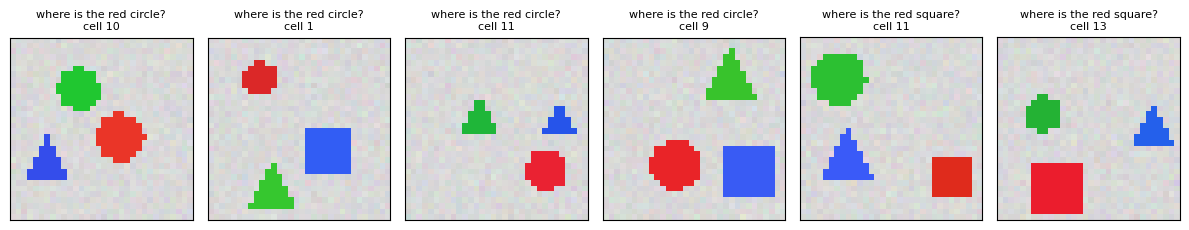

In [30]:
IMG = 32
COLOR_NAMES, SHAPE_NAMES = ['red', 'green', 'blue'], ['square', 'circle', 'triangle']
COLOR_RGB = np.array([[0.90, 0.15, 0.15], [0.15, 0.72, 0.20], [0.20, 0.35, 0.95]], np.float32)
_YS, _XS = np.mgrid[0:IMG, 0:IMG]


def shape_mask(shape, cx, cy, r):
    """Boolean mask of a square (0), circle (1) or triangle (2) centred at (cx, cy) with radius r."""
    if shape == 0:
        return (np.abs(_XS - cx) <= r) & (np.abs(_YS - cy) <= r)
    if shape == 1:
        return (_XS - cx) ** 2 + (_YS - cy) ** 2 <= r * r
    t = (_YS - (cy - r)) / (2.0 * r)
    return (_YS >= cy - r) & (_YS <= cy + r) & (np.abs(_XS - cx) <= r * t)


def make_shapes(n, seed):
    """n images with one red, one green and one blue shape. Returns images (n,3,32,32), queries (n,3,2), centres (n,3,2)."""
    rng = np.random.default_rng(seed)
    imgs = np.zeros((n, 3, IMG, IMG), np.float32)
    queries = np.zeros((n, 3, 2), np.int64)              # (colour, shape) of each object
    centres = np.zeros((n, 3, 2), np.float32)            # (cx, cy) of each object
    for i in range(n):
        img = np.full((IMG, IMG, 3), 0.85, np.float32) + rng.normal(0, 0.02, (IMG, IMG, 3)).astype(np.float32)
        placed = []
        for col in range(3):
            while True:
                r = rng.uniform(3, 5); cx = rng.uniform(r + 1, IMG - r - 1); cy = rng.uniform(r + 1, IMG - r - 1)
                if all((cx - px) ** 2 + (cy - py) ** 2 > (r + pr + 2) ** 2 for px, py, pr in placed):
                    break
            shp = int(rng.integers(0, 3))
            img[shape_mask(shp, cx, cy, r)] = COLOR_RGB[col] + rng.normal(0, 0.03, 3)
            placed.append((cx, cy, r)); queries[i, col] = (col, shp); centres[i, col] = (cx, cy)
        imgs[i] = np.clip(img, 0, 1).transpose(2, 0, 1)
    return (torch.from_numpy(imgs).to(device), torch.from_numpy(queries).to(device),
            torch.from_numpy(centres).to(device))


def cell_of(centres, G=4):
    """(cx, cy) -> index of the GxG cell containing it, row-major."""
    return (centres[..., 1] // (IMG / G)).long() * G + (centres[..., 0] // (IMG / G)).long()


t0 = time.time()
Simg_tr, Sq_tr, Sc_tr = make_shapes(2000, seed=0)
Simg_te, Sq_te, Sc_te = make_shapes(300, seed=1)
print(f'shapes: train {tuple(Simg_tr.shape)}, test {tuple(Simg_te.shape)}, generated in {time.time() - t0:.1f} s')

fig, ax = plt.subplots(1, 6, figsize=(12, 2.3))
for j in range(6):
    ax[j].imshow(to_np(Simg_te[j]).transpose(1, 2, 0)); ax[j].set_xticks([]); ax[j].set_yticks([])
    q = Sq_te[j, 0]
    ax[j].set_title(f'where is the {COLOR_NAMES[int(q[0])]} {SHAPE_NAMES[int(q[1])]}?\ncell {int(cell_of(Sc_te[j, 0]))}', fontsize=8)
plt.tight_layout(); plt.show()

In [31]:
class SpatialAttnModel(nn.Module):
    """CNN -> 8x8 grid of annotation vectors; the question attends over the grid; a head reads the cell."""
    def __init__(self, d=32, attention=True, grid=8):
        super().__init__()
        self.attention = attention
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),        # 32 -> 16
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),       # 16 -> 8
            nn.Conv2d(32, d - 2, 3, padding=1), nn.ReLU())
        ys, xs = torch.meshgrid(torch.linspace(-1, 1, grid), torch.linspace(-1, 1, grid), indexing='ij')
        self.register_buffer('coords', torch.stack([xs, ys])[None])           # (1, 2, grid, grid)
        self.q_emb = nn.Embedding(9, d)                                        # (colour, shape) -> s
        self.Wa = nn.Linear(d, d, bias=False)                                  # general attention s^T W_a a_i
        self.head = nn.Sequential(nn.Linear(2 * d, 64), nn.ReLU(), nn.Linear(64, 16))

    def annotations(self, img):
        f = self.cnn(img)                                                      # (B, d-2, 8, 8)
        f = torch.cat([f, self.coords.expand(f.shape[0], -1, -1, -1)], dim=1) # append (x, y) channels
        return f.flatten(2).transpose(1, 2)                                    # (B, 64, d): m*n vectors of length c

    def forward(self, img, query):
        A = self.annotations(img)
        s = self.q_emb(query[:, 0] * 3 + query[:, 1])
        if self.attention:
            alpha = torch.softmax(torch.einsum('bd,bld->bl', self.Wa(s), A), dim=-1)   # over 64 space-steps
            ctx = torch.einsum('bl,bld->bd', alpha, A)
        else:
            alpha, ctx = None, A.mean(1)                                       # one pooled vector, no grid left
        return self.head(torch.cat([ctx, s], dim=-1)), alpha


def train_spatial(attention, steps=700, lr=2e-3, seed=0):
    set_seed(seed)
    model = SpatialAttnModel(attention=attention).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    gen = torch.Generator().manual_seed(seed)
    t0 = time.time()
    for it in range(1, steps + 1):
        idx = torch.randint(0, len(Simg_tr), (64,), generator=gen).to(device)
        which = torch.randint(0, 3, (64,), generator=gen).to(device)
        img, q = Simg_tr[idx], Sq_tr[idx, which]
        target = cell_of(Sc_tr[idx, which])
        logits, _ = model(img, q)
        loss = F.cross_entropy(logits, target)
        opt.zero_grad(); loss.backward(); opt.step()
        if it % 175 == 0 or it == 1:
            print(f'  step {it:4d}  loss {loss.item():.3f}')
    print(f'  trained in {time.time() - t0:.1f} s')
    return model


@torch.no_grad()
def spatial_accuracy(model):
    accs = []
    for which in range(3):
        logits, _ = model(Simg_te, Sq_te[:, which])
        accs.append((logits.argmax(-1) == cell_of(Sc_te[:, which])).float().mean().item())
    return float(np.mean(accs))


print('attention over the 8x8 grid:')
sp_attn = train_spatial(attention=True)
print('pooled vector, no attention:')
sp_pool = train_spatial(attention=False)
acc_attn, acc_pool = spatial_accuracy(sp_attn), spatial_accuracy(sp_pool)
print(f'\nheld-out accuracy (16 cells, chance 0.0625):  attention {acc_attn:.3f}   pooled vector {acc_pool:.3f}')
assert acc_attn > 0.6 and acc_pool < 0.25, 'attention should locate objects, the pooled vector should not'

attention over the 8x8 grid:
  step    1  loss 2.782


  step  175  loss 2.650


  step  350  loss 1.208


  step  525  loss 0.518


  step  700  loss 0.530
  trained in 9.7 s
pooled vector, no attention:
  step    1  loss 2.782


  step  175  loss 2.663


  step  350  loss 2.549


  step  525  loss 2.680


  step  700  loss 2.532
  trained in 9.1 s

held-out accuracy (16 cells, chance 0.0625):  attention 0.849   pooled vector 0.093


The pooled model stays near chance: averaging the grid throws away *where* the features were, and the
question cannot recover it. The attention model answers most questions correctly, and its attention map
shows how: it lands on the object the question names. The overlays below are $\alpha$ upsampled from the
$8 \times 8$ grid to the image (bilinear), one per test image, for the red object's question.

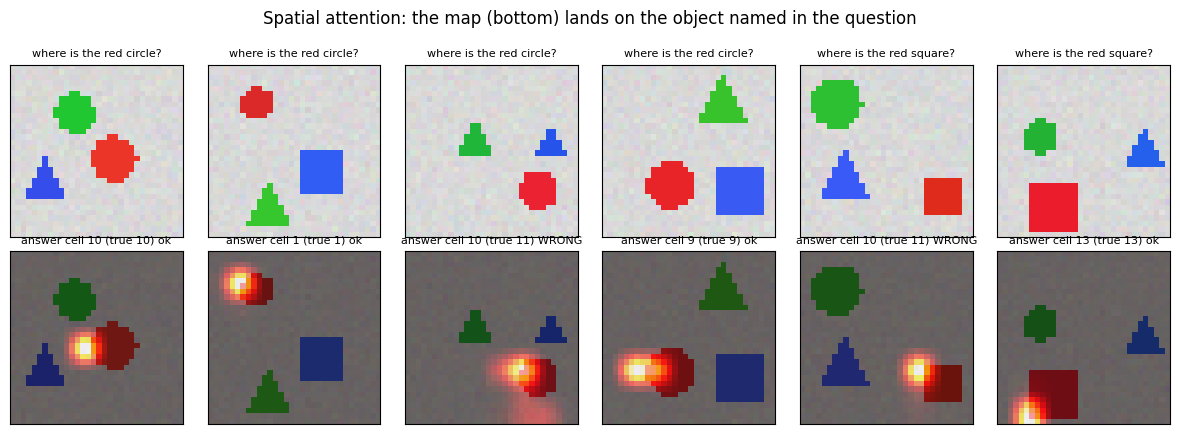

In [32]:
@torch.no_grad()
def attention_maps(model, imgs, queries):
    """Alpha over the 8x8 grid for each (image, query), upsampled to IMG x IMG for display. Returns numpy."""
    logits, alpha = model(imgs, queries)
    a = alpha.reshape(-1, 1, 8, 8)
    up = F.interpolate(a, size=(IMG, IMG), mode='bilinear', align_corners=False)
    return to_np(a[:, 0]), to_np(up[:, 0]), to_np(logits.argmax(-1))


N_SHOW = 8
sp_alpha, sp_up, sp_pred = {}, {}, {}
for which in range(3):
    sp_alpha[which], sp_up[which], sp_pred[which] = attention_maps(sp_attn, Simg_te[:N_SHOW], Sq_te[:N_SHOW, which])
sp_true = to_np(cell_of(Sc_te[:N_SHOW]))                     # (N_SHOW, 3)


def draw_query(ax_img, ax_att, i, which):
    q = to_np(Sq_te[i, which])
    img = to_np(Simg_te[i]).transpose(1, 2, 0)
    ax_img.imshow(img); ax_att.imshow(img); ax_att.imshow(sp_up[which][i], cmap='hot', alpha=0.55, vmin=0)
    ok = sp_pred[which][i] == sp_true[i, which]
    ax_img.set_title(f'where is the {COLOR_NAMES[q[0]]} {SHAPE_NAMES[q[1]]}?', fontsize=8)
    ax_att.set_title(f'answer cell {sp_pred[which][i]} (true {sp_true[i, which]}) {"ok" if ok else "WRONG"}', fontsize=8)
    for a_ in (ax_img, ax_att): a_.set_xticks([]); a_.set_yticks([])


fig, ax = plt.subplots(2, 6, figsize=(12, 4.3))
for j in range(6):
    draw_query(ax[0, j], ax[1, j], j, 0)
fig.suptitle('Spatial attention: the map (bottom) lands on the object named in the question', y=1.0)
plt.tight_layout(); plt.show()

### Widget 6: the attention map for each question

Pick a test `image` and an `object` (0 = red, 1 = green, 2 = blue). The overlay moves to whichever shape the
question names, on the same image, which is what makes this attention rather than saliency: the map
depends on the query, not only on the picture. The maps were computed above for eight test images and
all three questions; the widget only indexes them.

In [33]:
def show_spatial(image=0, obj=0):
    fig, ax = plt.subplots(1, 3, figsize=(10, 3.2))
    draw_query(ax[0], ax[1], image, obj)
    ax[2].imshow(sp_alpha[obj][image], cmap='hot', vmin=0)
    ax[2].set_title(f'raw 8x8 alpha, max {sp_alpha[obj][image].max():.2f}', fontsize=8)
    ax[2].set_xticks(range(8)); ax[2].set_yticks(range(8))
    plt.tight_layout(); plt.show()

interact(show_spatial, image=IntSlider(min=0, max=N_SHOW - 1, step=1, value=0, description='image'),
                       obj=IntSlider(min=0, max=2, step=1, value=0, description='object'));

interactive(children=(IntSlider(value=0, description='image', max=7), IntSlider(value=0, description='object',…

## 9. Byproduct of attention: explainability

The slides show two famous figures. Bahdanau's English-to-French alignment matrices, where the weights
reproduce word order (mostly diagonal, with the swap of *European Economic Area* into *zone économique
européenne* visible as a block off the diagonal), and the "Show, Attend and Tell" captions, where the
attention map at the moment the model says *frisbee* highlights the frisbee. Nobody designed those
explanations; they fall out of the weights $\alpha_{t,j}$, which exist because the mechanism needs them.

The same is true of the two models trained here. The figure shows alignment matrices for three held-out
sequences of different lengths, and the numbers quantify how much of the attention mass lands where an
explanation would want it.

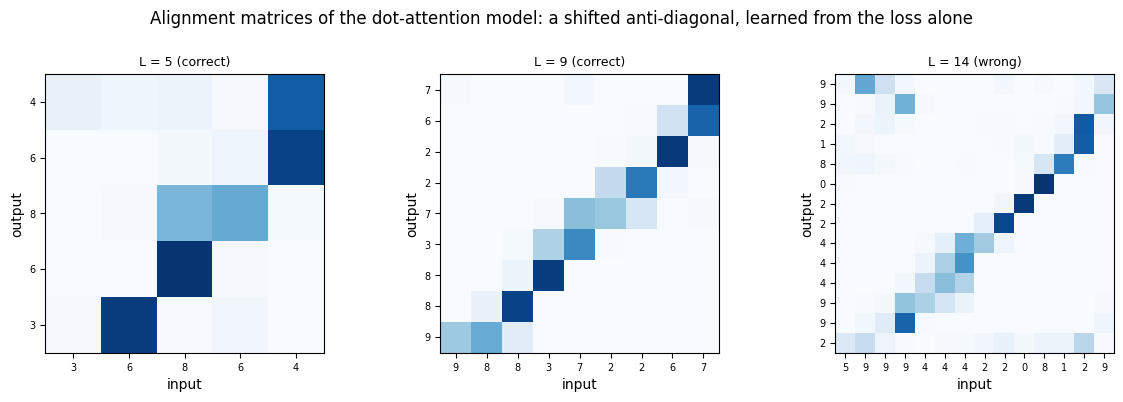

sequence model, L = 12, 300 sequences: mean alpha on the correct position 0.168, within one position 0.927, uniform would be 0.083
spatial model, 300 images x 3 questions: mean attention mass within one grid cell of the named object 0.975 (a 3x3 patch is 0.141 of the grid)


In [34]:
# Alignment matrices for three lengths, Bahdanau style.
fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
gen_al = torch.Generator().manual_seed(21)
for a_, Lx in zip(ax, (5, 9, 14)):
    x, y, _ = make_batch(1, Lx, Lx, gen_al)
    p, al = greedy_decode(enc1, dec1, x, Lx)
    a_.imshow(to_np(al[0]), cmap='Blues', vmin=0, vmax=1)
    a_.set_xticks(range(Lx)); a_.set_xticklabels([str(int(t)) for t in x[0]], fontsize=7)
    a_.set_yticks(range(Lx)); a_.set_yticklabels([str(int(t)) for t in p[0]], fontsize=7)
    a_.set_xlabel('input'); a_.set_ylabel('output')
    a_.set_title(f'L = {Lx} ({"correct" if (p[0] == y[0]).all() else "wrong"})', fontsize=9)
fig.suptitle('Alignment matrices of the dot-attention model: a shifted anti-diagonal, learned from the loss alone', y=1.02)
plt.tight_layout(); plt.show()

# How much attention mass sits on the correct source position, over many sequences?
gen_m = torch.Generator().manual_seed(5)
x, y, _ = make_batch(300, 12, 12, gen_m)
_, al = greedy_decode(enc1, dec1, x, 12)
idx = torch.arange(12, device=device)
mass_correct = al[0:, idx, 11 - idx].mean().item()           # alpha[t, L-1-t]
mass_within1 = (al[:, idx, 11 - idx] + al[:, idx, (10 - idx).clamp(0, 11)] * (idx < 11)
                + al[:, idx, (12 - idx).clamp(0, 11)] * (idx > 0)).mean().item()
print(f'sequence model, L = 12, 300 sequences: mean alpha on the correct position {mass_correct:.3f}, '
      f'within one position {mass_within1:.3f}, uniform would be {1 / 12:.3f}')

# And for the spatial model: attention mass within one grid cell of the object's centre.
with torch.no_grad():
    masses = []
    for which in range(3):
        _, alpha = sp_attn(Simg_te, Sq_te[:, which])
        a = alpha.reshape(-1, 8, 8)
        gx = (Sc_te[:, which, 0] // 4).long(); gy = (Sc_te[:, which, 1] // 4).long()
        ys, xs = torch.meshgrid(torch.arange(8, device=device), torch.arange(8, device=device), indexing='ij')
        near = ((xs[None] - gx[:, None, None]).abs() <= 1) & ((ys[None] - gy[:, None, None]).abs() <= 1)
        masses.append((a * near).sum((1, 2)).mean().item())
print(f'spatial model, 300 images x 3 questions: mean attention mass within one grid cell of the named object '
      f'{np.mean(masses):.3f} (a 3x3 patch is {9 / 64:.3f} of the grid)')

### 9.a A caveat: the weights are an explanation of the *computation*, not a proof about the *model*

The context vector is $c = A^\top \alpha$ with $A$ the $L \times c$ matrix of annotation vectors. Whenever
$L > c + 1$ the linear map $\alpha \mapsto (A^\top\alpha,\ \mathbf 1^\top \alpha)$ has a nullspace, so
there exist *different* valid weight vectors that produce *exactly the same* context vector and therefore
exactly the same answer. The cell constructs one for the spatial model, where $L = 64$ locations and
$c = 32$ channels leave a 31-dimensional nullspace. How far one can move is limited by non-negativity: the
weights that are already zero cannot go lower. So a **peaked** map is almost pinned down, whereas a
**diffuse** map (the same weights at a higher temperature, as an early-training or uncertain model would
produce) can be changed visibly without changing the context vector. Attention maps are a faithful record
of what was computed, but "the model looked here" is only as sharp as the map itself.

nullspace dimension: 31  (= 64 locations - 32 channels - 1 sum constraint)
peaked map (max weight 1.00):  largest same-context move ||alpha - alpha_alt||_1 = 0.0000
diffuse map (max weight 0.51): largest same-context move ||alpha - alpha_alt||_1 = 0.1833
the freedom lives where the weights are not (nearly) zero: a peaked map is pinned down, a diffuse one is not


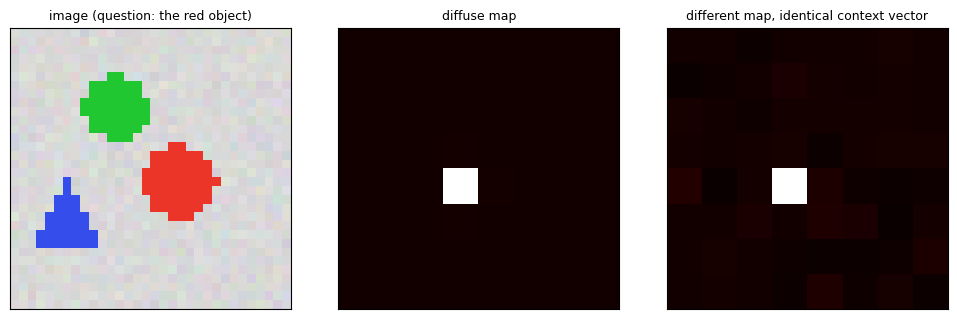

In [35]:
with torch.no_grad():
    A = sp_attn.annotations(Simg_te[:1])[0].cpu().double()                  # (64, 32)
    _, alpha0 = sp_attn(Simg_te[:1], Sq_te[:1, 0])
    alpha0 = alpha0[0].cpu().double()                                        # (64,) the model's weights
    alpha0 = alpha0 / alpha0.sum()                                           # renormalise exactly in float64
M = torch.cat([A.T, torch.ones(1, 64, dtype=torch.float64)], dim=0)         # (33, 64): context and sum constraints
_, Sv, Vh_M = torch.linalg.svd(M)
null = Vh_M[M.shape[0]:]                                                     # rows spanning the nullspace of M
print(f'nullspace dimension: {null.shape[0]}  (= 64 locations - 32 channels - 1 sum constraint)')
z = null.T @ torch.randn(null.shape[0], generator=torch.Generator().manual_seed(0), dtype=torch.float64)
z = z / z.abs().max()


def same_context_neighbour(alpha, z):
    """Move alpha along the nullspace direction z as far as non-negativity allows. Same context, same sum."""
    step_max = (alpha / z.clamp(max=-1e-12).abs()).min()                    # first weight to hit zero
    alpha_new = alpha + 0.9 * step_max * z
    assert (alpha_new >= 0).all() and abs(alpha_new.sum() - 1) < 1e-8
    assert (A.T @ alpha_new - A.T @ alpha).norm() < 1e-8, 'context vector must be unchanged'
    return alpha_new


alpha_diffuse = 0.5 * alpha0 + 0.5 / 64                                     # a high-temperature version of the same map
alpha0_alt = same_context_neighbour(alpha0, z)
alpha_diffuse_alt = same_context_neighbour(alpha_diffuse, z)
print(f'peaked map (max weight {alpha0.max():.2f}):  largest same-context move ||alpha - alpha_alt||_1 = {(alpha0 - alpha0_alt).abs().sum():.4f}')
print(f'diffuse map (max weight {alpha_diffuse.max():.2f}): largest same-context move ||alpha - alpha_alt||_1 = {(alpha_diffuse - alpha_diffuse_alt).abs().sum():.4f}')
print('the freedom lives where the weights are not (nearly) zero: a peaked map is pinned down, a diffuse one is not')

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2))
ax[0].imshow(to_np(Simg_te[0]).transpose(1, 2, 0)); ax[0].set_title('image (question: the red object)', fontsize=9)
ax[1].imshow(alpha_diffuse.reshape(8, 8).numpy(), cmap='hot', vmin=0); ax[1].set_title('diffuse map', fontsize=9)
ax[2].imshow(alpha_diffuse_alt.reshape(8, 8).numpy(), cmap='hot', vmin=0); ax[2].set_title('different map, identical context vector', fontsize=9)
for a_ in ax: a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout(); plt.show()

## 10. Modes of attention

The slides close with three distinctions.

**Hard versus soft.** Hard attention picks a **single position** with weight 1.0; the choice is stochastic
and therefore **non-differentiable**. Soft attention gives every position a partial weight in $(0, 1)$; it
is deterministic and therefore **differentiable**, which is why everything above could be trained by
ordinary backpropagation. Hard attention needs reinforcement-learning style estimators, which Lecture 2
discusses.

**Global versus local.** Global attention considers all input positions. Local attention restricts to a
**neighbourhood window around an aligned position** (*Luong et al., EMNLP 2015*), which is cheaper and can
be better when alignments are known to be roughly monotonic.

**Self-attention** (also called intra-attention) relates positions *within* a single sequence rather than
across two. The slides note it is used extensively in advanced models, which is Lecture 4 of this week.

### 10.a Hard versus soft

Soft attention becomes hard in the limit of a sharp softmax: multiply the scores by a sharpness $\beta$
(an inverse temperature) and the distribution converges to a one-hot vector at the argmax.

In [36]:
# Hard attention is the zero-temperature limit of soft attention.
scores_demo = torch.tensor([2.0, 0.5, 3.5, 1.0, 0.2])

print('  sharpness beta        attention weights                       max weight')
for beta in (0.5, 1, 2, 5, 20, 100):
    a = torch.softmax(beta * scores_demo, dim=0)
    print(f'    beta = {beta:5.1f}   {[round(v, 3) for v in a.tolist()]}   {a.max():.4f}')

hard = torch.zeros_like(scores_demo)
hard[scores_demo.argmax()] = 1.0
limit = torch.softmax(100 * scores_demo, dim=0)
assert torch.allclose(limit, hard, atol=1e-3), 'the beta -> infinity limit should be one-hot'
assert torch.allclose(hard.sum(), torch.tensor(1.0))

print(f'\n  hard attention = {hard.tolist()}  (one-hot, still sums to 1)')
print('  soft attention approaches it as the temperature falls; both are distributions')

  sharpness beta        attention weights                       max weight
    beta =   0.5   [0.217, 0.103, 0.46, 0.132, 0.088]   0.4600
    beta =   1.0   [0.16, 0.036, 0.718, 0.059, 0.026]   0.7184
    beta =   2.0   [0.047, 0.002, 0.943, 0.006, 0.001]   0.9431
    beta =   5.0   [0.001, 0.0, 0.999, 0.0, 0.0]   0.9994
    beta =  20.0   [0.0, 0.0, 1.0, 0.0, 0.0]   1.0000
    beta = 100.0   [0.0, 0.0, 1.0, 0.0, 0.0]   1.0000

  hard attention = [0.0, 0.0, 1.0, 0.0, 0.0]  (one-hot, still sums to 1)
  soft attention approaches it as the temperature falls; both are distributions


In [37]:
# Why "non-differentiable" matters: sampling a position blocks the gradient.
logits = torch.randn(5, requires_grad=True)

soft_w = torch.softmax(logits, dim=0)
soft_out = (soft_w * torch.arange(5.0)).sum()
soft_out.backward()
soft_grad = logits.grad.clone()

logits.grad = None
with torch.no_grad():                          # sampling is not a differentiable operation
    idx = torch.multinomial(torch.softmax(logits, dim=0), 1)
hard_out = torch.arange(5.0)[idx].sum()
has_grad = hard_out.requires_grad

print(f'  soft attention: gradient reaches the logits, norm = {soft_grad.norm():.4f}')
print(f'  hard attention: sampled output requires_grad = {has_grad}  -> no gradient path')
print('\n  this is exactly what the slides mean by "position-choosing is stochastic')
print('  and hence non-differentiable"')

  soft attention: gradient reaches the logits, norm = 0.6321
  hard attention: sampled output requires_grad = False  -> no gradient path

  this is exactly what the slides mean by "position-choosing is stochastic
  and hence non-differentiable"


A soft-trained model can be run with hard attention at test time: replace $\alpha_t$ by a one-hot vector at
its argmax (the deterministic version of hard attention) before forming $c_t$. The trained weights are
peaked but not one-hot (Section 6.b showed the mass split between two neighbouring positions, and about
0.5 nats of entropy remain), so the model loses about ten points of accuracy on the lengths it was trained
on, and happens to gain a little at $L = 16$, where the soft weights had become diffuse. The `alpha_fn` hook
on the decoder makes this a one-line change.

In [38]:
def hard_argmax(alpha):
    """Deterministic hard attention: all mass on the argmax position."""
    return F.one_hot(alpha.argmax(-1), alpha.shape[-1]).to(alpha.dtype)

test_L = (4, 8, 12, 16)
acc_soft = accuracy_by_length(enc1, dec1, test_L)              # same test draw for both modes
dec1.alpha_fn = hard_argmax
acc_hard = accuracy_by_length(enc1, dec1, test_L)
dec1.alpha_fn = None
print('  length          ' + ' '.join(f'{L:5d}' for L in test_L))
print('  soft (trained)  ' + ' '.join(f'{acc_soft[L]:5.2f}' for L in test_L))
print('  hard at test    ' + ' '.join(f'{acc_hard[L]:5.2f}' for L in test_L))
gen_e = torch.Generator().manual_seed(3)
x, _, _ = make_batch(300, 12, 12, gen_e)
_, al = greedy_decode(enc1, dec1, x, 12)
ent = -(al * (al + 1e-12).log()).sum(-1).mean().item()
drop = np.mean([acc_soft[L] - acc_hard[L] for L in test_L if L <= L_TRAIN_MAX])
print(f'\n  mean entropy of the trained weights at L = 12: {ent:.3f} nats (uniform over 12 would be {math.log(12):.3f});')
print(f'  the weights are peaked but not one-hot, and snapping them costs {100 * drop:.0f} points on the training lengths')

  length              4     8    12    16
  soft (trained)   0.95  0.96  0.92  0.36
  hard at test     0.87  0.84  0.81  0.47

  mean entropy of the trained weights at L = 12: 0.504 nats (uniform over 12 would be 2.485);
  the weights are peaked but not one-hot, and snapping them costs 10 points on the training lengths


### 10.b Global versus local

Local attention keeps only a window of half-width $D$ around an **aligned position** $p_t$ and renormalises.
Luong et al. either set $p_t = t$ (monotonic alignment) or predict it with a small network. Here the trained
global model supplies $p_t$ as the position of its own largest score, which isolates the effect of the window:
$D = 0$ is hard attention, $D \ge L - 1$ is global attention. A second run centres the window at $p_t = t$
instead, the monotonic assumption, which is *wrong* for a reversal task, and shows that local attention is
only as good as its alignment prior.

In [39]:
def local_window(D, centre='argmax'):
    """Return an alpha_fn that zeroes weights farther than D from the aligned position and renormalises."""
    def fn(alpha):
        B, Tsrc = alpha.shape
        pos = torch.arange(Tsrc, device=alpha.device)[None, :].expand(B, -1)
        if centre == 'argmax':
            p = alpha.argmax(-1, keepdim=True)
        else:                                          # monotonic: p_t = t, tracked by a counter on the closure
            p = torch.full((B, 1), fn.t, device=alpha.device); fn.t += 1
        keep = (pos - p).abs() <= D
        a = alpha * keep
        return a / a.sum(-1, keepdim=True).clamp(min=1e-12)
    fn.t = 0
    return fn


D_VALUES = list(range(0, 12))
acc_global_12 = accuracy_by_length(enc1, dec1, [12])[12]        # the reference, on the same test draw
acc_local, acc_mono = {}, {}
for D in D_VALUES:
    dec1.alpha_fn = local_window(D, 'argmax')
    acc_local[D] = accuracy_by_length(enc1, dec1, [12])[12]
    # the monotonic variant needs its step counter reset before every decode: evaluate one batch of length 12
    fn = local_window(D, 'monotonic'); dec1.alpha_fn = fn
    x, y, _ = make_batch(300, 12, 12, torch.Generator().manual_seed(1))
    fn.t = 0
    pred, _ = greedy_decode(enc1, dec1, x, 12)
    acc_mono[D] = (pred == y).all(1).float().mean().item()
dec1.alpha_fn = None

print('  half-width D           ' + ' '.join(f'{D:4d}' for D in D_VALUES))
print('  window at argmax       ' + ' '.join(f'{acc_local[D]:4.2f}' for D in D_VALUES))
print('  window at p_t = t      ' + ' '.join(f'{acc_mono[D]:4.2f}' for D in D_VALUES))
print(f'\n  global attention on the same sequences: {acc_global_12:.2f};  D = 11 covers every position: {acc_local[11]:.2f}')
assert abs(acc_local[11] - acc_global_12) < 1e-6, 'a window covering everything is global attention'
assert acc_mono[0] < 0.1, 'the monotonic centre points at the wrong token for a reversal'

  half-width D              0    1    2    3    4    5    6    7    8    9   10   11
  window at argmax       0.83 0.94 0.93 0.93 0.93 0.93 0.93 0.93 0.93 0.93 0.93 0.93
  window at p_t = t      0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.02 0.08 0.51 0.93

  global attention on the same sequences: 0.93;  D = 11 covers every position: 0.93


The window at the aligned position changes nothing measurable for every $D \ge 1$, because the global model
was already looking at one or two adjacent positions; $D = 0$ is hard attention and costs the ten points seen
above. The window at $p_t = t$ destroys the model for small $D$ and only recovers once
the window is wide enough to contain the correct position $L - 1 - t$ (which is $|2t - L + 1|$ away, so $D$
must reach $L - 1$ for the first and last steps). The sweep below draws the masked weights for one
sequence; the widget lets you slide $D$.

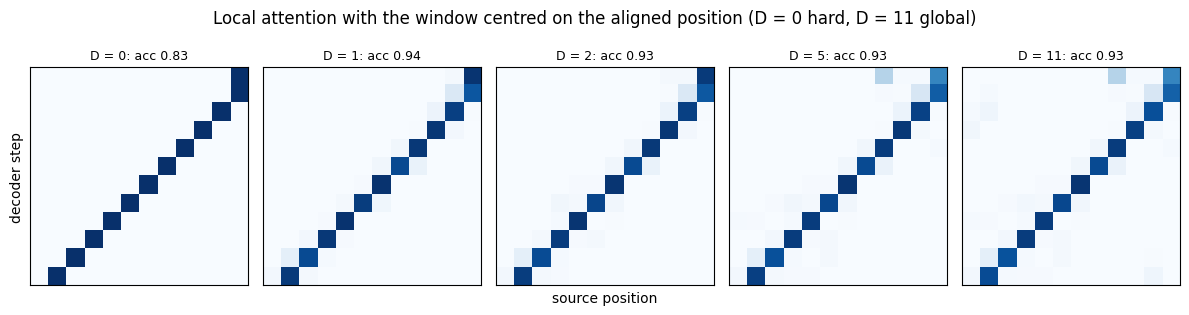

In [40]:
# Static sweep: the masked alignment matrix for one sequence at several D (window centred on the argmax).
x_loc, y_loc, _ = make_batch(1, 12, 12, torch.Generator().manual_seed(9))
loc_maps = {}
for D in D_VALUES:
    dec1.alpha_fn = local_window(D, 'argmax')
    p, al = greedy_decode(enc1, dec1, x_loc, 12)
    loc_maps[D] = dict(alpha=to_np(al[0]), pred=fmt(p[0]), ok=bool((p[0] == y_loc[0]).all()))
dec1.alpha_fn = None

fig, ax = plt.subplots(1, 5, figsize=(12, 2.9))
for a_, D in zip(ax, (0, 1, 2, 5, 11)):
    a_.imshow(loc_maps[D]['alpha'], cmap='Blues', vmin=0, vmax=1)
    a_.set_title(f'D = {D}: acc {acc_local[D]:.2f}', fontsize=9); a_.set_xticks([]); a_.set_yticks([])
ax[0].set_ylabel('decoder step'); ax[2].set_xlabel('source position')
fig.suptitle('Local attention with the window centred on the aligned position (D = 0 hard, D = 11 global)', y=1.02)
plt.tight_layout(); plt.show()

### Widget 7: the local window

Drag `D`. The left panel is the masked alignment matrix, the right panel is the accuracy at $L = 12$ for
both ways of placing the window. With the window on the aligned position the matrix and the accuracy are
the same at every $D \ge 1$ ($D = 0$ is hard attention and loses the ten points of Section 10.a); with the
monotonic centre, accuracy climbs only when $D$ is large enough for the window to reach across the sequence.

In [41]:
def show_local(D=2):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={'width_ratios': [1, 1.4]})
    ax[0].imshow(loc_maps[D]['alpha'], cmap='Blues', vmin=0, vmax=1)
    ax[0].set_xticks(range(12)); ax[0].set_yticks(range(12)); ax[0].set_xlabel('source position'); ax[0].set_ylabel('decoder step')
    ax[0].set_title(f'D = {D}: output {"correct" if loc_maps[D]["ok"] else "wrong"}', fontsize=9)
    ax[1].plot(D_VALUES, [acc_local[k] for k in D_VALUES], 'o-', color='seagreen', label='window at aligned position')
    ax[1].plot(D_VALUES, [acc_mono[k] for k in D_VALUES], 's-', color='firebrick', label='window at $p_t = t$')
    ax[1].axvline(D, color='k', ls='--', lw=0.8)
    ax[1].set_xlabel('half-width D'); ax[1].set_ylabel('accuracy at L = 12'); ax[1].set_ylim(-0.03, 1.05)
    ax[1].grid(alpha=0.3); ax[1].legend(loc='center right', fontsize=8)
    plt.tight_layout(); plt.show()

interact(show_local, D=IntSlider(min=0, max=11, step=1, value=2, description='D'));

interactive(children=(IntSlider(value=2, description='D', max=11), Output()), _dom_classes=('widget-interact',…

### 10.c Self-attention

In self-attention the queries, keys and values all come from the **same** sequence: every position attends
over every other position of its own sequence, $\alpha_{i,j} = \operatorname{softmax}_j(h_i^\top h_j / \sqrt d)$
and $z_i = \sum_j \alpha_{i,j} h_j$. It is the scaled dot-product score of Section 7 applied with $s = h_i$.
The cell computes it from scratch on the encoder states of a test sequence, checks it against
`nn.MultiheadAttention` with one head and identity projections, and plots the $T \times T$ matrix (the
figure in the slides, from *Cheng et al., EMNLP 2016*, is the same object drawn as arcs between words).

self-attention from scratch matches nn.MultiheadAttention: max |dZ| = 1.79e-07, max |dA| = 1.19e-07
each row of A is a distribution over the 12 positions: row sums [1.0, 1.0, 1.0, 1.0] ...


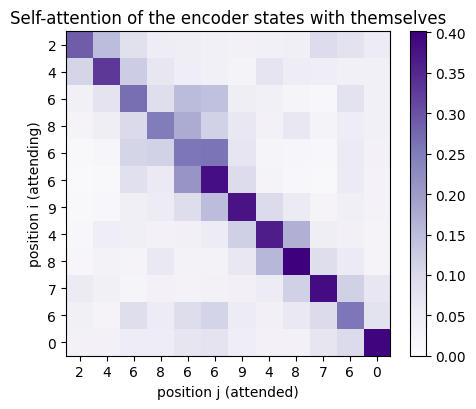

In [42]:
def self_attention_scratch(Hs):
    """Scaled dot-product self-attention over one sequence Hs (T, d). Returns outputs (T, d) and weights (T, T)."""
    A = torch.softmax(Hs @ Hs.T / math.sqrt(Hs.shape[-1]), dim=-1)
    return A @ Hs, A

x_sa, _, _ = make_batch(1, 12, 12, torch.Generator().manual_seed(13))
with torch.no_grad():
    Hs, _ = enc1(x_sa)
    Hs = Hs[0]                                                        # (12, 32) encoder states
    Z, A_self = self_attention_scratch(Hs)

    mha = nn.MultiheadAttention(embed_dim=Hs.shape[1], num_heads=1, bias=False, batch_first=True).to(device)
    mha.in_proj_weight.copy_(torch.eye(Hs.shape[1], device=device).repeat(3, 1))    # Q = K = V = H
    mha.out_proj.weight.copy_(torch.eye(Hs.shape[1], device=device))
    Z_ref, A_ref = mha(Hs[None], Hs[None], Hs[None])
assert torch.allclose(Z, Z_ref[0], atol=1e-5) and torch.allclose(A_self, A_ref[0], atol=1e-5)
print(f'self-attention from scratch matches nn.MultiheadAttention: max |dZ| = {(Z - Z_ref[0]).abs().max():.2e}, '
      f'max |dA| = {(A_self - A_ref[0]).abs().max():.2e}')
print(f'each row of A is a distribution over the 12 positions: row sums {to_np(A_self.sum(-1)).round(4).tolist()[:4]} ...')

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(to_np(A_self), cmap='Purples', vmin=0)
toks = [str(int(t)) for t in x_sa[0]]
ax.set_xticks(range(12)); ax.set_xticklabels(toks); ax.set_yticks(range(12)); ax.set_yticklabels(toks)
ax.set_xlabel('position j (attended)'); ax.set_ylabel('position i (attending)')
ax.set_title('Self-attention of the encoder states with themselves')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 11. Explore and verify

The attention weights are the whole story, so the last section checks them against PyTorch's own
implementations and then hands the temperature over to you.

First, the batched attention step inside `AttnDecoder` is compared with `F.scaled_dot_product_attention`
(the query is $s_{t-1}$, the keys and values are the encoder states) and with `nn.MultiheadAttention`, on
the real states of the trained model. Then the properties every attention distribution must have are
asserted for all five score functions of Section 7.

In [43]:
# 1. The decoder's attention step against F.scaled_dot_product_attention and nn.MultiheadAttention.
x_v, _, _ = make_batch(16, 12, 12, torch.Generator().manual_seed(2))
with torch.no_grad():
    H_v, hT_v = enc1(x_v)                                            # (16, 12, 32), (16, 32)
    mask_v = x_v != PAD
    dec_scaled = AttnDecoder(N_TOK, d_model, score='scaled').to(device)
    c_scratch, alpha_scratch = dec_scaled.context(hT_v, H_v, mask_v)

    # reference 1: F.scaled_dot_product_attention with the decoder state as a length-1 query
    c_ref = F.scaled_dot_product_attention(hT_v[:, None, :], H_v, H_v)[:, 0]
    # reference 2: nn.MultiheadAttention, one head, identity projections
    mha1 = nn.MultiheadAttention(d_model, 1, bias=False, batch_first=True).to(device)
    mha1.in_proj_weight.copy_(torch.eye(d_model, device=device).repeat(3, 1))
    mha1.out_proj.weight.copy_(torch.eye(d_model, device=device))
    c_mha, alpha_mha = mha1(hT_v[:, None, :], H_v, H_v)

assert torch.allclose(c_scratch, c_ref, atol=1e-5), 'context vs F.scaled_dot_product_attention'
assert torch.allclose(c_scratch, c_mha[:, 0], atol=1e-5), 'context vs nn.MultiheadAttention'
assert torch.allclose(alpha_scratch, alpha_mha[:, 0], atol=1e-5), 'weights vs nn.MultiheadAttention'
print(f'scaled dot-product context: max |diff| vs F.scaled_dot_product_attention {(c_scratch - c_ref).abs().max():.2e}, '
      f'vs nn.MultiheadAttention {(c_scratch - c_mha[:, 0]).abs().max():.2e}')

# 2. Verify the properties every attention distribution must satisfy.
for name, fn in [('dot', score_dot), ('scaled', score_scaled),
                 ('general', score_general), ('cosine', score_cosine),
                 ('additive', score_additive)]:
    a = torch.softmax(fn(s_prev, H), dim=0)
    assert a.shape == (T,), f'{name}: wrong shape'
    assert torch.allclose(a.sum(), torch.tensor(1.0, device=device), atol=1e-6), f'{name}: does not sum to 1'
    assert (a >= 0).all(), f'{name}: negative weight'
    c = a @ H
    assert c.shape == (dh,), f'{name}: context vector has the wrong width'
    # The context vector is a convex combination, so it lies inside the convex hull of the states.
    assert c.norm() <= H.norm(dim=1).max() + 1e-4, f'{name}: context escaped the convex hull'
    print(f'  {name:9s} entropy {-(a * a.log()).sum():.3f} nats, max weight {a.max():.3f}')

print(f'\n  all five produce a valid distribution over {T} positions and a {dh}-d context vector')
print(f'  uniform attention would have entropy log({T}) = {np.log(T):.3f} nats')

scaled dot-product context: max |diff| vs F.scaled_dot_product_attention 1.79e-07, vs nn.MultiheadAttention 1.79e-07
  dot       entropy 0.055 nats, max weight 0.992
  scaled    entropy 1.376 nats, max weight 0.557
  general   entropy 0.026 nats, max weight 0.996
  cosine    entropy 1.920 nats, max weight 0.210
  additive  entropy 1.443 nats, max weight 0.394

  all five produce a valid distribution over 7 positions and a 16-d context vector
  uniform attention would have entropy log(7) = 1.946 nats


The last experiment is the sharpness $\beta$, an inverse temperature multiplied into the scores. It leaves
the ranking of the source positions untouched (scaled and unscaled dot products share their argmax, as
Section 7 checked) and changes only how much of the mass the winner gets: small $\beta$ is uniform
averaging, large $\beta$ is hard attention. The sweep shows five values on the states of Section 6.

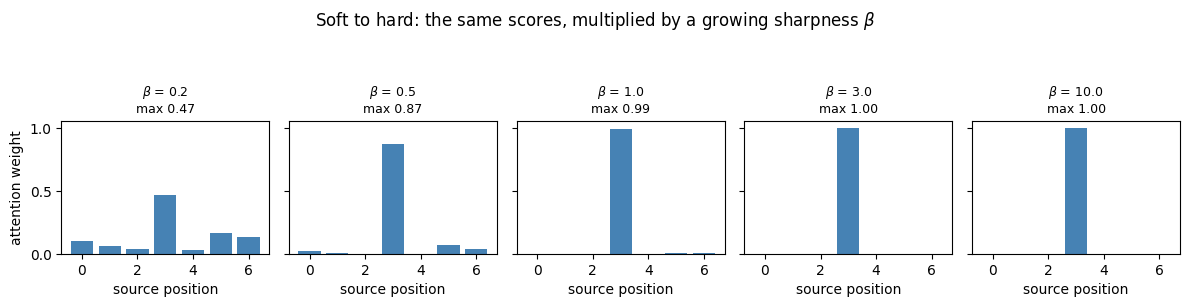

In [44]:
# Static sweep: the sharpness beta (an inverse temperature) turns soft attention into hard attention.
fig, ax = plt.subplots(1, 5, figsize=(12, 2.8), sharey=True)
raw = H @ s_prev
for a_, beta in zip(ax, [0.2, 0.5, 1.0, 3.0, 10.0]):
    w = torch.softmax(beta * raw, dim=0)
    a_.bar(range(T), to_np(w), color='steelblue')
    a_.set_title(f'$\\beta$ = {beta}\nmax {w.max():.2f}', fontsize=9)
    a_.set_xlabel('source position')
ax[0].set_ylabel('attention weight')
fig.suptitle('Soft to hard: the same scores, multiplied by a growing sharpness $\\beta$', y=1.08)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [45]:
def show_temperature(beta=1.0):
    w = torch.softmax(beta * raw, dim=0)
    ent = -(w * (w + 1e-12).log()).sum()
    fig, a_ = plt.subplots(figsize=(7, 3))
    a_.bar(range(T), to_np(w), color='steelblue')
    a_.set_xlabel('source position'); a_.set_ylabel('attention weight'); a_.set_ylim(0, 1)
    a_.set_title(f'dot-product attention, $\\beta$ = {beta:.2f}   entropy {ent:.2f} nats   max {w.max():.2f}')
    plt.tight_layout(); plt.show()

interact(show_temperature, beta=FloatSlider(min=0.05, max=20, step=0.05, value=1.0, description='beta'));

interactive(children=(FloatSlider(value=1.0, description='beta', max=20.0, min=0.05, step=0.05), Output()), _d…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Encoder-decoder** | One network summarises the input into a representation, another generates from it; the context vector's size and the parameter count do not depend on the input length |
| **Autoencoder** | The unsupervised special case, target $y_i = x_i$, loss $\|x - \hat x\|_2^2$; reconstruction error falls steeply up to a bottleneck of about 16 and then flattens |
| **Denoising AE** | Corrupt the input, predict the clean one: the model must learn the manifold because the noise is unpredictable; measured to beat the plain AE once the test noise reaches about $\sigma = 0.3$, and by a widening margin beyond |
| **Under / overcomplete** | An undercomplete code is a dimensionality reduction; an overcomplete linear code learned the identity and copied noise images as well as digits |
| **AE and PCA** | Linear encoder and decoder, centred inputs, MSE loss: the AE reaches PCA's reconstruction error, its decoder spans the PCA subspace ($P_{\text{AE}} = V_kV_k^\top$) and equals $V_k R$ for an invertible $R$ |
| **The bottleneck** | A fixed-length context vector has finite capacity: the seq2seq model's exact-match accuracy fell from 1.00 at $L = 2$ to 0.03 at $L = 10$ and 0.00 at $L = 12$, the analogue of BLEU degrading with sentence length |
| **Attention** | $c_t = \sum_j \alpha_{t,j} h_j$ with $\alpha_{t,j} = \operatorname{softmax}_j\,score(s_{t-1}, h_j)$: a fresh context vector at every step, built from all encoder states; it lifted the same model to near-perfect reversal on every training length and graceful degradation (0.82 to 0.40) on the four lengths it never saw |
| **Score functions** | Dot-product is general with $W_a = I$; cosine is dot-product on normalised vectors; scaling changes temperature, not argmax; location-based ignores $h$; additive costs $2dk + k$ parameters, the dot family costs none |
| **Space-steps** | Unroll the $m \times n \times c$ feature volume into $mn$ annotation vectors and attend over them; the FC or pooled vector has no spatial structure left, and the pooled model stayed at chance on "where is the red square?" |
| **Explainability** | The weights are viewable for free and land where a human would look, but different weightings can produce the identical context vector |
| **Modes** | Hard picks one position (stochastic, non-differentiable); soft weights all positions (differentiable); local restricts to a window around an aligned position and is only as good as that alignment; self-attention relates a sequence to itself |

**The three models at a glance**

| Model | Task | Held-out result | What it shows |
|---|---|---|---|
| Autoencoder, DAE, linear AE | MNIST reconstruction | MSE vs $k$ and $\sigma$; PCA subspace recovered | Encoder-decoder without a decoder sequence |
| Seq2seq, no attention vs dot vs additive | Reverse a digit sequence | Accuracy vs length: collapse without attention, graceful with | The bottleneck and its removal |
| CNN grid + query attention vs pooled vector | "Where is the red square?" | High accuracy with attention, chance without | Time-steps become space-steps |

## Exercises

1. **The homework from the slides.** What is the connection between an autoencoder and Principal Component
   Analysis? State the three conditions under which they coincide, and explain why the decoder found in
   Section 4 was $V_k R$ rather than $V_k$. Then break one condition at a time: add a bias, skip the centring,
   or replace MSE by the L1 loss, and report $\|P_{\text{AE}} - P_{\text{PCA}}\|_F$ for each.
   *(Answer: linear encoder and decoder, dimension-wise centred inputs, MSE loss. The loss depends on $W$
   only through the subspace it spans, so every basis of that subspace is a minimiser and gradient descent
   lands on whichever one it reaches first. In Section 4 the projectors differed by 0.002 in Frobenius norm
   and the reconstruction error was within 0.004% of the PCA optimum.)*

2. **Entropy as a diagnostic.** Uniform attention over $T$ positions has entropy $\log T$. Using
   `greedy_decode` on the dot-attention model, plot the entropy of $\alpha_t$ against the decoder step $t$
   for $L = 12$ and $L = 16$, and say what a sudden rise would mean. *(At $L = 12$ we measured a mean of
   about 0.5 nats against a uniform value of 2.48, most of it from the mass split between two adjacent
   positions; expect the rise to appear at the steps where the $L = 16$ outputs go wrong.)*

3. **When does scaling matter?** Scaled dot-product divides by $\sqrt n$. Generate random unit-variance
   states for growing $d \in \{8, 32, 128, 512\}$ and show what happens to the softmax entropy without the
   scaling. What goes wrong first, the weights or their gradients? Then retrain `AttnDecoder` with
   `score='scaled'` and `d=128` and compare with `'dot'` at the same width.

4. **Local attention with a learned centre.** Section 10.b took the aligned position from the global
   scores. Implement Luong's predictive alignment $p_t = L \cdot \sigma(v_p^\top \tanh(W_p s_t))$, train it,
   and report accuracy at $L = 12$ as a function of $D$. At what $D$ does it match global attention?
   *(With the centre taken from the global scores, $D = 0$, which is hard attention, gave 0.83 and every
   $D \ge 1$ gave 0.93; with $p_t = t$, $D$ had to reach 11.)*

5. **Attention as explanation.** Section 9.a constructed a second weight vector with the same context
   vector by moving inside the nullspace of $[A^\top; \mathbf 1^\top]$. Repeat the construction for the
   sequence model at $L = 12$ with $d = 32$: does a nullspace exist? Explain what changes when
   $L \le d + 1$, and what that says about how much of the "explanation" is pinned down by the data.

6. **Train the remaining score functions.** Add `'general'` and `'scaled'` to the comparison of Section
   7.a with the same 1500 steps, and report the mean accuracy over lengths 1 to 12 for all four attention
   variants against the no-attention baseline. Which of the pairs proved equivalent in Section 7 also
   behave alike when trained?